# Trabalho de Instalações Elétricas: Trabalho 1
## UFRJ | Escola Politécnica | EEE472
### Memória de Cálculo e Projeto Luminotécnico

**Integrantes:** Eduardo Motta e Anderson Santiago  
**DREs:** 123488210 e 125092366   
**Professor:** Juan Ramón Camarillo Peñaranda  
**Data:** Outubro de 2026


# Escopo do Trabalho

Este notebook reúne os cálculos feitos para o projeto de uma residência unifamiliar em baixa tensão, seguindo a divisão das Etapas 0 a 6 proposta no roteiro do Trabalho 1 e usando como base o conteúdo apresentado nas aulas, junto com as normas e o padrão de fornecimento indicados para o projeto.

As principais referências usadas ao longo dos cálculos foram:

* ABNT NBR 5410:2004.
* RECON-BT Light 2026.
* ABNT NBR ISO/CIE 8995-1:2013.
* Aulas 00 a 06 da disciplina.

A ideia foi desenvolver cada parte na mesma ordem em que os assuntos apareceram nas aulas, deixando os valores intermediários visíveis para facilitar o acompanhamento dos cálculos e para relacionar os resultados numéricos com as escolhas feitas no projeto.


In [217]:
# carrega as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import pandas as pd
import scipy as sp
import warnings
import math

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.size": 14,
    "font.sans-serif": ["Helvetica", "Arial", "Dejavu Sans"],
})

# Okabe-Ito colorblind-friendly palette
color_blind_palette = [
    (0.902, 0.624, 0.000),   # Orange
    (0.337, 0.706, 0.914),   # Sky Blue
    (0.000, 0.620, 0.451),   # Bluish Green
    (0.941, 0.894, 0.259),   # Yellow
    (0.000, 0.447, 0.698),   # Blue
    (0.835, 0.369, 0.000),   # Vermillion
    (0.800, 0.475, 0.655),   # Reddish Purple
]

# Global matplotlib style settings
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        14,
    'axes.grid':        True,
    'grid.color':       '#D9D9D9',
    'grid.linestyle':   '--',
    'axes.linewidth':   1.2,
    'figure.figsize':   (7, 14/3),   # ~600px wide, 2/3 aspect
})

# Etapa 0: Parametrização dos DREs

In [218]:
V_pn = 127
V_pp = 220

# DREs e dígitos sintéticos
DRE_a = 125092366
DRE_b = 123488210

digitos_a = np.array([int(d) for d in str(DRE_a)])
digitos_b = np.array([int(d) for d in str(DRE_b)])
S = (digitos_a + digitos_b) % 10

print("Dígitos sintéticos S =", S)

# Parâmetros geométricos
A_tot = 85 + np.sum(S[:4])
L = 8.0 + 0.5 * (S[4] % 5)
C = A_tot / L
h = 2.70 + 0.10 * (S[5] % 4)
L_alim = 15 + 2 * (S[6] % 6)
L_crit = 16 + 2 * (S[7] % 6)

# Parâmetros luminotécnicos
R_lum = S[8] % 3
h_pendural_sala = 0.40 + 0.10 * (S[4] % 4)
h_pendural_cozinha = 0.00
h_pendural_suite = 0.00
d_lumens = 0.85

# TUEs parametrizadas
P_chuv1 = 5500 + 1000 * (S[0] % 3)
P_chuv2 = 5500
P_mot_cv = 0.5 + 0.25 * (S[1] % 4)
P_mot_w = P_mot_cv * 736
P_micro = 1200 + 100 * (S[2] % 4)
P_airfryer = 1500 + 200 * (S[3] % 3)
P_ar_suite = 1100
P_ar_quartos = 850

parametros = pd.DataFrame([
    ["Dígitos sintéticos", str(S.tolist()), "-"],
    ["Área total A_tot", A_tot, "m²"],
    ["Largura externa L", L, "m"],
    ["Comprimento externo C", C, "m"],
    ["Pé-direito h", h, "m"],
    ["Comprimento do alimentador L_alim", L_alim, "m"],
    ["Comprimento crítico L_crit", L_crit, "m"],
    ["Código luminotécnico R_lum", R_lum, "-"],
    ["Pendural da sala", h_pendural_sala, "m"],
    ["Chuveiro suíte", P_chuv1, "W"],
    ["Chuveiro social", P_chuv2, "W"],
    ["Motobomba", P_mot_cv, "cv"],
    ["Micro-ondas", P_micro, "W"],
    ["Airfryer", P_airfryer, "W"],
    ["Ar-condicionado suíte", P_ar_suite, "W"],
    ["Ar-condicionado quartos", P_ar_quartos, "W"],
], columns=["Parâmetro", "Valor", "Unidade"])

display(parametros)


Dígitos sintéticos S = [2 4 8 4 7 0 5 7 6]


,Parâmetro,Valor,Unidade
0,Dígitos sintéticos,"[2, 4, 8, 4, 7, 0, 5, 7, 6]",-
1,Área total A_tot,103,m²
2,Largura externa L,9.0,m
3,Comprimento externo C,11.444444,m
4,Pé-direito h,2.7,m
5,Comprimento do alimentador L_alim,25,m
6,Comprimento crítico L_crit,18,m
7,Código luminotécnico R_lum,0,-
8,Pendural da sala,0.7,m
9,Chuveiro suíte,7500,W


# Configuração Arquitetônica

A distribuição dos ambientes foi montada a partir das exigências do enunciado e das dimensões obtidas pelos DREs, procurando manter uma planta simples para que o lançamento das cargas e dos circuitos pudesse ser acompanhado com mais facilidade. Depois de montar o croqui, a área construída foi comparada com a área calculada pelos DREs para verificar se a diferença permanecia dentro da tolerância de 5% indicada no trabalho.


,Cômodo / Ambiente,Tipo (NBR 5410),Dimensões (C x L),Área (m²),Perímetro (m)
,Sala de Estar / Jantar,Área Seca Social,"4,00m x 5,50m",22.0,19.0
,Cozinha,Área Molhada,"3,00m x 4,00m",12.0,14.0
,Área de Serviço,Área Molhada,"3,00m x 1,50m",4.5,9.0
,Quarto 1,Área Seca Íntima,"3,00m x 3,50m",10.5,13.0
,Quarto 2,Área Seca Íntima,"3,00m x 3,50m",10.5,13.0
,Suíte Máster,Área Seca Íntima,"4,00m x 3,50m",14.0,15.0
,Banheiro da Suíte,Área Molhada,"3,00m x 1,50m",4.5,9.0
,Banheiro Social,Área Molhada,"2,00m x 2,00m",4.0,8.0
,Corredor,Área de Circulação,"7,00m x 1,00m",7.0,16.0
,Garagem Coberta,Área Externa Coberta,"3,00m x 5,00m",15.0,16.0


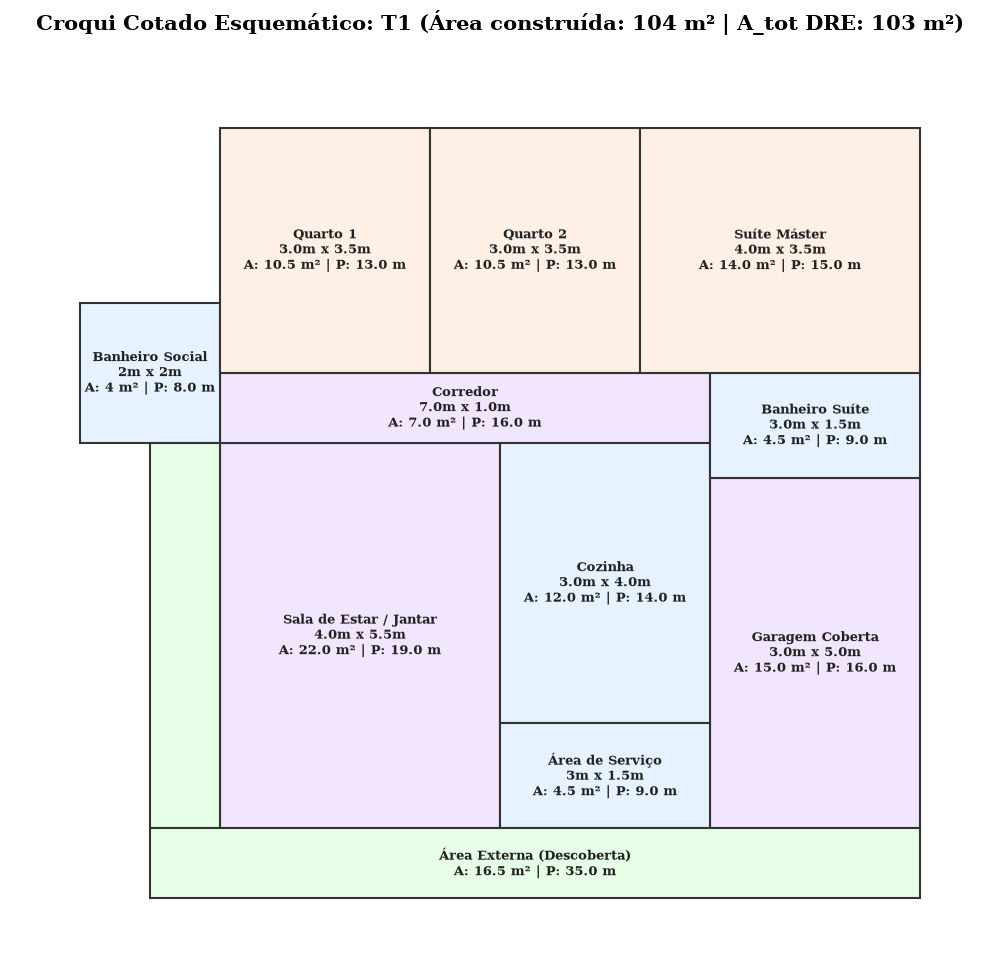

Área parametrizada pelos DREs: 103.0 m²
Área construída no croqui: 104.0 m²
Desvio: +0.97% -> ATENDE ao limite de ±5%.


In [219]:
def plotar_croqui():
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Formato: (x, y, largura, comprimento, Nome, Area, Perimetro, Cor)
    comodos = [
        # Setor Social / Acesso (Tons de Azul/Cinza)
        (0, 0, 4.0, 5.5, "Sala de Estar / Jantar", 22.0, 19.0, '#f2e6ff'),
        (7, 0, 3.0, 5.0, "Garagem Coberta", 15.0, 16.0, '#f2e6ff'),
        (0, 5.5, 7.0, 1.0, "Corredor", 7.0, 16.0, '#f2e6ff'),
        # x0, y0, x, y
        # Setor de Serviço / Molhado (Tons de Verde/Amarelo)
        (4, 1.5, 3.0, 4.0, "Cozinha", 12.0, 14.0, '#e6f2ff'),
        (4, 0, 3, 1.5, "Área de Serviço", 4.5, 9.0, '#e6f2ff'),
        (7, 5, 3.0, 1.5, "Banheiro Suíte", 4.5, 9.0, '#e6f2ff'),
        (-2, 5.5, 2, 2, "Banheiro Social", 4, 8.0, '#e6f2ff'),
        
        # Setor Íntimo (Tons de Laranja/Pêssego)
        (0, 6.5, 3.0, 3.5, "Quarto 1", 10.5, 13.0, '#fff0e6'),
        (3, 6.5, 3.0, 3.5, "Quarto 2", 10.5, 13.0, '#fff0e6'),
        (6, 6.5, 4.0, 3.5, "Suíte Máster", 14.0, 15.0, '#fff0e6'),
        
        # Área Externa Descoberta (dividida em duas partes para formar o L, mas com texto só em uma)
        (-1.0, 0, 1.0, 5.5, "", "", "", '#e6ffe6'),
        (-1.0, -1.0, 11.0, 1.0, "Área Externa (Descoberta)", 16.5, 35.0, '#e6ffe6')
    ]
    
    # Desenha cada cômodo
    for (x, y, largura, comprimento, nome, area, perimetro, cor) in comodos:
        retangulo = patches.Rectangle((x, y), largura, comprimento, 
                                      linewidth=1.5, edgecolor='#333333', facecolor=cor)
        ax.add_patch(retangulo)
        
        # Imprime o texto apenas se houver um nome definido para o bloco
        if nome != "":
            # Para cômodos normais ou áreas compostas, ajustamos a exibição do texto:
            if "Área Externa" in nome:
                texto_cota = f"{nome}\nA: {area} m² | P: {perimetro} m"
            else:
                texto_cota = f"{nome}\n{largura}m x {comprimento}m\nA: {area} m² | P: {perimetro} m"
            
            ax.text(x + largura/2, y + comprimento/2, texto_cota, 
                    ha='center', va='center', fontsize=9, weight='bold', color='#222222')

    # Configurações do gráfico
    ax.set_xlim(-3, 11)
    ax.set_ylim(-2, 11)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.title(f"Croqui Cotado Esquemático: T1 (Área construída: 104 m² | A_tot DRE: {A_tot} m²)", fontsize=15, weight='bold', pad=20)
    plt.tight_layout()
    plt.show()

def gerar_quadro_resumo_comodos():
    dados_comodos = [
        {"Cômodo / Ambiente": "Sala de Estar / Jantar", "Tipo (NBR 5410)": "Área Seca Social", "Dimensões (C x L)": "4,00m x 5,50m", "Área (m²)": 22.00, "Perímetro (m)": 19.00},
        {"Cômodo / Ambiente": "Cozinha", "Tipo (NBR 5410)": "Área Molhada", "Dimensões (C x L)": "3,00m x 4,00m", "Área (m²)": 12.00, "Perímetro (m)": 14.00},
        {"Cômodo / Ambiente": "Área de Serviço", "Tipo (NBR 5410)": "Área Molhada", "Dimensões (C x L)": "3,00m x 1,50m", "Área (m²)": 4.50, "Perímetro (m)": 9.00},
        {"Cômodo / Ambiente": "Quarto 1", "Tipo (NBR 5410)": "Área Seca Íntima", "Dimensões (C x L)": "3,00m x 3,50m", "Área (m²)": 10.50, "Perímetro (m)": 13.00},
        {"Cômodo / Ambiente": "Quarto 2", "Tipo (NBR 5410)": "Área Seca Íntima", "Dimensões (C x L)": "3,00m x 3,50m", "Área (m²)": 10.50, "Perímetro (m)": 13.00},
        {"Cômodo / Ambiente": "Suíte Máster", "Tipo (NBR 5410)": "Área Seca Íntima", "Dimensões (C x L)": "4,00m x 3,50m", "Área (m²)": 14.00, "Perímetro (m)": 15.00},
        {"Cômodo / Ambiente": "Banheiro da Suíte", "Tipo (NBR 5410)": "Área Molhada", "Dimensões (C x L)": "3,00m x 1,50m", "Área (m²)": 4.50, "Perímetro (m)": 9.00},
        {"Cômodo / Ambiente": "Banheiro Social", "Tipo (NBR 5410)": "Área Molhada", "Dimensões (C x L)": "2,00m x 2,00m", "Área (m²)": 4.00, "Perímetro (m)": 8.00},
        {"Cômodo / Ambiente": "Corredor", "Tipo (NBR 5410)": "Área de Circulação", "Dimensões (C x L)": "7,00m x 1,00m", "Área (m²)": 7.00, "Perímetro (m)": 16.00},
        {"Cômodo / Ambiente": "Garagem Coberta", "Tipo (NBR 5410)": "Área Externa Coberta", "Dimensões (C x L)": "3,00m x 5,00m", "Área (m²)": 15.00, "Perímetro (m)": 16.00},
        {"Cômodo / Ambiente": "Total Construída", "Tipo (NBR 5410)": "--", "Dimensões (C x L)": "Composta", "Área (m²)": 104.0, "Perímetro (m)": 44.00},
        {"Cômodo / Ambiente": "Área Externa (Descoberta)", "Tipo (NBR 5410)": "Área Livre / Quintal", "Dimensões (C x L)": "Composta", "Área (m²)": 16.50, "Perímetro (m)": 35.00}        
    ]
    
    df = pd.DataFrame(dados_comodos)

    # Tirando os índices
    df.index = [''] * len(df)

    display(df)
    return df

tabela_comodos = gerar_quadro_resumo_comodos()

# Gerar o croqui
plotar_croqui()

# Conferência geométrica exigida pelo enunciado
area_construida_croqui = 104.0
desvio_area_pct = 100 * (area_construida_croqui - A_tot) / A_tot
print(f"Área parametrizada pelos DREs: {A_tot:.1f} m²")
print(f"Área construída no croqui: {area_construida_croqui:.1f} m²")
print(f"Desvio: {desvio_area_pct:+.2f}% -> {'ATENDE' if abs(desvio_area_pct) <= 5 else 'NÃO ATENDE'} ao limite de ±5%.")


## Classes auxiliares

In [220]:
class Carga:
    def __init__(self, descricao, potencia_va, x, y, z, fp="x", rendimento="x", categoria = "x"):
        self.descricao = descricao
        self.x = x
        self.y = y
        self.z = z #altura da tomada
        self.fp = fp
        self.rendimento = rendimento
        self.categoria = categoria
        # Armazena o valor inicial recebido em potencia_va ################################ falar com o Edu se a gente coloca entrada em VA ou em W ATENÇÃO
        self.potencia_va = float(potencia_va)
        
        # Aplica o cálculo do rendimento (se aplicável)
        self.aplicar_rendimento(rendimento)
        
        # Aplica o cálculo do fator de potência (se aplicável)
        self.aplicar_fator_potencia(fp)
        
        # Arredonda ou converte para inteiro ao final para manter o padrão
        self.potencia_va = int(round(self.potencia_va))

    def aplicar_rendimento(self, rendimento):
        """Aplica o rendimento (eta) dividindo a potência por ele, caso não seja 'x'."""
        if rendimento is not None and str(rendimento).strip().lower() != 'x':
            eta = float(rendimento)
            if eta > 0:
                self.potencia_va = self.potencia_va / eta

    def aplicar_fator_potencia(self, fp):
        """Aplica o fator de potência (cos φ) dividindo a potência por ele, caso não seja 'x'."""
        if fp is not None and str(fp).strip().lower() != 'x':
            fator = float(fp)
            if fator > 0:
                self.potencia_va = self.potencia_va / fator

class Comodo:
    def __init__(self, nome, tipo, area, perimetro):
        self.nome = nome
        self.tipo = tipo.lower()
        self.area = area
        self.perimetro = perimetro
        self.potencia_iluminacao_va = 0
        self.quantidade_tugs = 0
        self.potencia_tugs_va = 0
        
    def prever_cargas_nbr5410(self):
        """Calcula a potência mínima de iluminação e TUGs conforme NBR 5410."""
        
        # --- TRATAMENTO PARA ÁREA EXTERNA DESCOBERTA ---
        if self.tipo in ['externa_descoberta', 'quintal', 'jardim']:
            self.potencia_iluminacao_va = 200  # Ex: 2 arandelas/refletores de 100VA
            self.quantidade_tugs = 2
            self.potencia_tugs_va = 200  # 2 x 100VA
            
        # --- ÁREAS MOLHADAS INTERNAS ---
        elif self.tipo in ['cozinha', 'copa', 'área de serviço', 'lavanderia']:
            # Iluminação por área
            if self.area > 6:
                adicionais = math.floor((self.area - 6) / 4)
            else: 
                adicionais = 0
            self.potencia_iluminacao_va = 100 + (adicionais * 60) if self.area > 6 else 100
            
            # TUGs por perímetro (3.5m)
            self.quantidade_tugs = math.ceil(self.perimetro / 3.5)
            if self.quantidade_tugs <= 3:
                self.potencia_tugs_va = self.quantidade_tugs * 600
            else:
                self.potencia_tugs_va = (3 * 600) + ((self.quantidade_tugs - 3) * 100)
                
        # --- BANHEIROS ---
        elif self.tipo == 'banheiro':
            self.potencia_iluminacao_va = 100 if self.area <= 6 else 100 + (math.floor((self.area - 6) / 4) * 60)
            self.quantidade_tugs = 1
            self.potencia_tugs_va = 600
            
        # --- DEMAIS CÔMODOS INTERNOS (Áreas Secas) ---
        else: 
            if self.area <= 6:
                self.potencia_iluminacao_va = 100
            else:
                adicionais = math.floor((self.area - 6) / 4)
                self.potencia_iluminacao_va = 100 + (adicionais * 60)
                
            self.quantidade_tugs = max(1, math.ceil(self.perimetro / 5))
            self.potencia_tugs_va = self.quantidade_tugs * 100

class ProjetoEletrico:
    def __init__(self):
        self.cargas_posicionadas = []
        self.comodos = []

    def limpar_comodos(self):
        """Limpa os cômodos já inseridos para evitar acúmulo ao rodar a célula novamente."""
        self.comodos.clear()

    def adicionar_comodo(self, comodo):
        if comodo not in self.comodos:
            self.comodos.append(comodo)

    def calcular_baricentro(self):
        """Calcula o centro de carga lendo os cômodos dinamicamente."""
        soma_px = 0.0
        soma_py = 0.0
        potencia_total = 0.0
        
        for carga in self.cargas_posicionadas:
            soma_px += carga.potencia_va * carga.x
            soma_py += carga.potencia_va * carga.y
            potencia_total += carga.potencia_va
            
        if potencia_total == 0:
            return 0.0, 0.0
            
        return (soma_px / potencia_total), (soma_py / potencia_total)

    def adicionar_carga(self, carga):
            self.cargas_posicionadas.append(carga)
            vetor_cargas = []
            vetor_cargas.append(carga)
        
    def limpar_cargas(self):
            self.cargas_posicionadas = []

class Circuito:
    def __init__(self, nome_circuito, descricao_circuito, tipo_circuito, potencia_circuito, tensao_circuito, corrente_circuito, secao_minima_circuito):
        self.nome = nome_circuito
        self.descricao = descricao_circuito
        self.tipo = tipo_circuito
        self.potencia = potencia_circuito
        self.tensao = tensao_circuito
        self.corrente = corrente_circuito
        self.secao_minima = secao_minima_circuito
        self.cargas_posicionadas = []
        self.comodos = []

    def adicionar_carga(self, carga):
        self.cargas_posicionadas.append(carga)
        
    def limpar_cargas(self):
        self.cargas_posicionadas.clear()

    def calcular_demanda_total(self):
        demanda_total = sum(carga.potencia_va for carga in self.cargas_posicionadas)
        return demanda_total

    def calcular_corrente_total(self):
        demanda_total = self.calcular_demanda_total()
        corrente_total = demanda_total / self.tensao if self.tensao != 0 else 0
        return corrente_total

    def calcular_fct(self, temp_ambiente=30, temp_max_isolacao=70):
        """Calcula o Fator de Correção de Temperatura (Fct)."""
        if temp_ambiente == 30:
            return 1.0
        else:
            fct_calc = math.sqrt((temp_max_isolacao - temp_ambiente) / (temp_max_isolacao - 30))
            return round(fct_calc, 2)

    def calcular_fca(self, agrupamento=1):
        """Calcula o Fator de Correção de Agrupamento (Fca)."""
        tabela_fca = {1: 1.00, 2: 0.80, 3: 0.70, 4: 0.65, 5: 0.60, 6: 0.57}
        return tabela_fca.get(agrupamento, 0.50 if agrupamento >= 7 else 1.00)

    def obter_secao_minima_normativa(self):
        """Define a seção mínima exigida pela NBR 5410 (Tabela 47) com base no tipo ou nome."""
        tipo = str(self.tipo).strip().casefold()
        nome = str(self.nome).strip().casefold()

        if tipo in {"iluminação", "iluminacao", "luz"} or nome.startswith(("luz-", "ilum-")):
            return 1.5
        elif tipo == "tug" or nome.startswith("tug-"):
            return 2.5
        elif tipo == "tue":
            return 2.5
        else:
            return self.secao_minima if self.secao_minima else 2.5

    def calcular_secao_minima(self):
        """Calcula a seção pelo critério de ampacidade respeitando a seção mínima da norma."""
        corrente_total = self.calcular_corrente_total()
        secao_piso = self.obter_secao_minima_normativa()

        # Cobre/PVC 70 °C, método B1, dois condutores carregados.
        ampacidades_b1_2cc = [
            (1.5, 17.5), (2.5, 24.0), (4.0, 32.0), (6.0, 41.0),
            (10.0, 57.0), (16.0, 76.0), (25.0, 101.0), (35.0, 125.0),
            (50.0, 151.0), (70.0, 192.0), (95.0, 232.0), (120.0, 269.0),
            (150.0, 309.0), (185.0, 353.0), (240.0, 415.0)
        ]

        for secao, corrente_admissivel in ampacidades_b1_2cc:
            if secao >= secao_piso and corrente_total <= corrente_admissivel:
                return secao

        raise ValueError(
            f"Corrente de {corrente_total:.2f} A excede a tabela B1 para dois condutores carregados."
        )

    def calcular_secao_dimensionada(self, temp_ambiente=30, agrupamento=1):
        """
        Calcula a seção transversal aplicando a seção mínima normativa, 
        os fatores de correção (Fct e Fca) e a capacidade de condução de corrente.
        """
        corrente_total = self.calcular_corrente_total()
        secao_piso = self.obter_secao_minima_normativa()

        # Aplica os fatores de correção de temperatura e agrupamento
        fct = self.calcular_fct(temp_ambiente)
        fca = self.calcular_fca(agrupamento)
        
        # Corrente de projeto corrigida (I'B)
        corrente_corrigida = corrente_total / (fct * fca) if (fct * fca) > 0 else corrente_total

        # Tabela de ampacidades (Cobre/PVC 70 °C, método B1, dois condutores carregados)
        ampacidades_b1_2cc = [
            (1.5, 17.5), (2.5, 24.0), (4.0, 32.0), (6.0, 41.0),
            (10.0, 57.0), (16.0, 76.0), (25.0, 101.0), (35.0, 125.0),
            (50.0, 151.0), (70.0, 192.0), (95.0, 232.0), (120.0, 269.0),
            (150.0, 309.0), (185.0, 353.0), (240.0, 415.0)
        ]

        for secao, corrente_admissivel in ampacidades_b1_2cc:
            if secao >= secao_piso and corrente_corrigida <= corrente_admissivel:
                return {
                    "fct": fct,
                    "fca": fca,
                    "corrente_projeto": round(corrente_total, 2),
                    "corrente_corrigida": round(corrente_corrigida, 2),
                    "secao_final": secao
                }

    @staticmethod
    def calcular_distancia_3d(ponto_a, ponto_b):
        """
        Calcula a distância do percurso ortogonal entre dois pontos em 3D.

        Para instalações elétricas, considera-se o caminho por trechos ortogonais:
        d = |x2-x1| + |y2-y1| + |z2-z1|.
        """
        if len(ponto_a) != 3 or len(ponto_b) != 3:
            raise ValueError("Cada ponto deve ser informado como (x, y, z).")

        return (
            abs(float(ponto_b[0]) - float(ponto_a[0])) +
            abs(float(ponto_b[1]) - float(ponto_a[1])) +
            abs(float(ponto_b[2]) - float(ponto_a[2]))
        )       
            
    def calcular_comprimento_vizinho_mais_proximo(self, x_qdc=5.5, y_qdc=4.5, z_qdc=1.4):
            """
            Calcula o comprimento do circuito pela heurística do vizinho mais próximo.
    
            A sequência do percurso é:
                QDC -> carga mais próxima -> carga mais próxima da anterior -> ...
    
            O comprimento total é a soma de cada trecho entre pontos consecutivos.
            """
            if not self.cargas_posicionadas:
                self.comprimento_circuito = 0.0
                self.rota_cargas = []
                return 0.0
    
            cargas_restantes = list(self.cargas_posicionadas)
            comprimento_total = 0.0
            ponto_atual = (x_qdc, y_qdc, z_qdc)
            rota = []
    
            while cargas_restantes:
                carga_proxima = min(
                    cargas_restantes,
                    key=lambda c: self.calcular_distancia_3d(
                        ponto_atual, (c.x, c.y, c.z)
                    )
                )
    
                ponto_proxima = (carga_proxima.x, carga_proxima.y, carga_proxima.z)
                distancia_trecho = self.calcular_distancia_3d(ponto_atual, ponto_proxima)
                comprimento_total += distancia_trecho
    
                rota.append({
                    "carga": carga_proxima,
                    "distancia_trecho_m": distancia_trecho,
                })
    
                ponto_atual = ponto_proxima
                cargas_restantes.remove(carga_proxima)
    
            self.comprimento_circuito = round(comprimento_total, 2)
            self.rota_cargas = rota
            return self.comprimento_circuito

    def calcular_secao_queda_tensao_otimizada(self, secao_ampacidade, x_qdc=5.5, y_qdc=4.5, z_qdc=1.4, delta_v_adm_pct=4.0):
        """
        Calcula a queda de tensão e a seção necessária utilizando o comprimento 
        otimizado pelo vizinho mais próximo em 3D.
        Garante que a seção adotada não seja menor que a seção exigida pela ampacidade.
        """
        # Obtém o comprimento real em metros
        comprimento = self.calcular_comprimento_vizinho_mais_proximo(x_qdc, y_qdc, z_qdc)
        corrente_projeto = self.calcular_corrente_total()
        rho = 0.01786  # Resistividade do cobre a 20°C (ohms*mm²/m)
        
        # Identifica a seção mínima normativa de piso (ex: 1.5mm² ilum ou 2.5mm² tomadas)
        secao_piso = self.obter_secao_minima_normativa()
        
        # A SEÇÃO DEFINITIVA não pode ser menor que o piso normativo NEM menor que a do critério de ampacidade
        secao_minima_exigida = max(secao_piso, secao_ampacidade)

        # Todos os circuitos terminais deste projeto têm dois condutores carregados.
        fator_formula = 200
            
        # 1º Passo: Calcula a seção exata necessária apenas para a queda de tensão limite (ex: 4%)
        secao_calc_queda = (fator_formula * rho * comprimento * corrente_projeto) / (delta_v_adm_pct * self.tensao)
            
        secoes_padrao = [1.5, 2.5, 4.0, 6.0, 10.0, 16.0, 25.0, 35.0, 50.0]
        secao_escolhida = 50.0 # Valor de segurança padrão
        
        # 2º Passo: Escolhe o cabo comercial que atende TODOS os critérios
        for secao in secoes_padrao:
            if secao >= secao_calc_queda and secao >= secao_minima_exigida:
                secao_escolhida = secao
                break
                
        # 3º Passo: Calcula a Queda de Tensão Real (%) com o cabo comercial escolhido
        if secao_escolhida > 0:
            queda_tensao_real_pct = (fator_formula * rho * comprimento * corrente_projeto) / (secao_escolhida * self.tensao)
        else:
            queda_tensao_real_pct = 0.0
                
        return {
            "comprimento_m": round(comprimento, 2),
            "corrente_projeto_a": round(corrente_projeto, 2),
            "secao_calc_queda_exata": round(secao_calc_queda, 2),
            "secao_ampacidade_ref": secao_ampacidade,
            "secao_comercial_final": secao_escolhida,
            "queda_tensao_real_pct": round(queda_tensao_real_pct, 2)
        }

    def calcular_secao_neutro(self, secao_fase, circuito_trifasico=False):
        """
        Dimensiona o condutor Neutro conforme a NBR 5410.
        Para circuitos monofásicos ou bifásicos, o neutro é igual à fase.
        Para circuitos trifásicos com fases > 25 mm², admite redução conforme tabela.
        """
        if not circuito_trifasico or secao_fase <= 25.0:
            return secao_fase
        
        tabela_neutro = {
            35.0: 25.0,
            50.0: 25.0,
            70.0: 35.0,
            95.0: 50.0,
            120.0: 70.0,
            150.0: 70.0,
            185.0: 95.0,
            240.0: 120.0
        }
        return tabela_neutro.get(secao_fase, secao_fase)

    def calcular_secao_pe(self, secao_fase):
        """
        Dimensiona o condutor de Proteção (PE) conforme o método simplificado 
        (Tabela 58 da NBR 5410), admitindo condutores do mesmo material (Cobre).
        """
        # Para fases até 16 mm², o PE é igual à fase
        if secao_fase <= 16.0:
            return secao_fase
        # Para fases entre 16 e 35 mm², o PE é fixado em 16 mm²
        elif 16.0 < secao_fase <= 35.0:
            return 16.0
        # Para fases maiores que 35 mm², o PE é a metade da fase
        else:
            secao_calc_pe = secao_fase / 2.0
            
            # Ajusta para a seção comercial imediatamente superior ou igual
            secoes_comerciais = [25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0, 240.0]
            for secao in secoes_comerciais:
                if secao >= secao_calc_pe:
                    return secao
            return secao_calc_pe

    def calcular_eletroduto(self, secao_fase, secao_neutro, secao_pe, num_fases=1):
        """
        Dimensiona o eletroduto de PVC antichama com base na área externa 
        total dos cabos e na taxa máxima de ocupação permitida pela NBR 5410.
        """
        # Áreas externas aproximadas para cabos isolados em PVC 750V (em mm²)
        area_cabos = {
            1.5: 8.0, 2.5: 11.0, 4.0: 14.5, 6.0: 18.1,
            10.0: 28.3, 16.0: 40.7, 25.0: 60.8, 35.0: 80.1, 50.0: 113.1
        }
        
        # Diâmetros comerciais de eletrodutos e suas áreas internas úteis (em mm²)
        eletrodutos_comerciais = [
            {"tamanho": "16 mm (1/2\")", "area_interna": 113.0},
            {"tamanho": "20 mm (3/4\")", "area_interna": 181.0},
            {"tamanho": "25 mm (1\")", "area_interna": 283.0},
            {"tamanho": "32 mm (1 1/4\")", "area_interna": 530.0},
            {"tamanho": "40 mm (1 1/2\")", "area_interna": 855.0},
            {"tamanho": "50 mm (2\")", "area_interna": 1385.0}
        ]
        
        # 1. Obtém as áreas unitárias de cada condutor
        a_fase = area_cabos.get(secao_fase, secao_fase * 2.5)
        a_neutro = area_cabos.get(secao_neutro, secao_neutro * 2.5) if secao_neutro > 0 else 0
        a_pe = area_cabos.get(secao_pe, secao_pe * 2.5) if secao_pe > 0 else 0
        
        # 2. Soma das áreas e quantidade de condutores no trecho
        qtd_cabos = num_fases + (1 if secao_neutro > 0 else 0) + (1 if secao_pe > 0 else 0)
        area_total_ocupada = (num_fases * a_fase) + a_neutro + a_pe
        
        # 3. Taxa de ocupação máxima (NBR 5410)
        if qtd_cabos == 1:
            taxa_ocupacao = 0.53
        elif qtd_cabos == 2:
            taxa_ocupacao = 0.31
        else:
            taxa_ocupacao = 0.40
            
        area_minima_necessaria = area_total_ocupada / taxa_ocupacao
        
        # 4. Seleção do eletroduto comercial adequado
        for eletroduto in eletrodutos_comerciais:
            if eletroduto["area_interna"] >= area_minima_necessaria:
                taxa_real = (area_total_ocupada / eletroduto["area_interna"]) * 100
                return {
                    "eletroduto": eletroduto["tamanho"],
                    "area_ocupada_mm2": round(area_total_ocupada, 2),
                    "taxa_real_pct": round(taxa_real, 1),
                    "limite_norma_pct": int(taxa_ocupacao * 100)
                }
                
        return {
            "eletroduto": "Especial > 50mm",
            "area_ocupada_mm2": round(area_total_ocupada, 2),
            "taxa_real_pct": ">40.0",
            "limite_norma_pct": int(taxa_ocupacao * 100)
        }

    def especificar_disjuntor(self, corrente_corrigida_iz):
        """
        Especifica a corrente nominal (In) e a curva do disjuntor termomagnético 
        conforme a NBR 5410, assegurando a proteção contra sobrecargas (IB <= In <= I'z).
        """
        corrente_projeto = self.calcular_corrente_total()
        
        # Correntes nominais comerciais padrão para mini disjuntores (NBR IEC 60898)
        correntes_comerciais = [6, 10, 16, 20, 25, 32, 40, 50, 63, 70, 80, 100, 125]
        
        disjuntor_escolhido = None
        
        # 1. Tenta encontrar um disjuntor que atenda perfeitamente a inequação da norma
        for in_val in correntes_comerciais:
            if corrente_projeto <= in_val <= corrente_corrigida_iz:
                disjuntor_escolhido = in_val
                break
                
        # 2. Caso de contingência: se o cabo suportar bem mas faltar ajuste exato, 
        # pega o menor disjuntor comercial superior ou igual à corrente de projeto
        if disjuntor_escolhido is None:
            for in_val in correntes_comerciais:
                if in_val >= corrente_projeto:
                    disjuntor_escolhido = in_val
                    break
                    
        # Curva D fica reservada à motobomba de partida direta.
        nome = str(self.nome).strip().casefold()
        if "mot" in nome:
            curva = "Curva D"
        else:
            curva = "Curva C"
            
        return {
            "disjuntor_in": disjuntor_escolhido,
            "curva": curva,
            "validacao_in_iz": disjuntor_escolhido <= corrente_corrigida_iz
        }

# Etapa 1: Previsão de cargas

Para começar o levantamento das cargas, foi usada a regra apresentada em aula para iluminação residencial, em que ambientes com até 6 m² recebem 100 VA e, acima dessa área, são acrescentados 60 VA para cada 4 m² inteiros adicionais. No código essa regra foi aplicada diretamente para cada cômodo, de modo que a potência de iluminação acompanhasse a área de cada ambiente.

Para áreas de até 6 m²:

$$
S_{\mathrm{ilum}} = 100\ \mathrm{VA}
$$

Para áreas maiores que 6 m²:

$$
S_{\mathrm{ilum}} =
100 + 60\left\lfloor\frac{A-6}{4}\right\rfloor\ \mathrm{VA}
$$

Para as tomadas de uso geral, a quantidade foi definida de acordo com o tipo de ambiente e com o seu perímetro, seguindo as regras usadas na NBR 5410 e trabalhadas em aula, com tratamento diferente para cozinha, área de serviço, banheiros e demais cômodos da residência.


In [221]:
# Inicializa o projeto elétrico e limpa instâncias anteriores
projeto_eletrico = ProjetoEletrico()
projeto_eletrico.limpar_comodos()

# Instanciando os cômodos individualmente e guardando nas variáveis de referência

sala = Comodo("Sala de Estar / Jantar", "sala", 22.0, 19.0)
cozinha = Comodo("Cozinha", "cozinha", 12.0, 14.0)
area_servico = Comodo("Área de Serviço", "área de serviço", 4.5, 9.0)
quarto1 = Comodo("Quarto 1", "quarto", 10.5, 13.0)
quarto2 = Comodo("Quarto 2", "quarto", 10.5, 13.0)
suite = Comodo("Suíte Máster", "quarto", 14.0, 15.0)
banh_suite = Comodo("Banheiro da Suíte", "banheiro", 4.5, 9.0)
banh_social = Comodo("Banheiro Social", "banheiro", 4.0, 8.0)
corredor = Comodo("Corredor", "circulação", 7.0, 16.0)
garagem = Comodo("Garagem Coberta", "externa", 15.0, 16.0)
area_externa = Comodo("Área Externa (Descoberta)", "externa_descoberta", 16.5, 35.0)

ambientes = [
    sala, 
    cozinha, 
    area_servico, 
    quarto1, 
    quarto2, 
    suite, 
    banh_suite, 
    banh_social, 
    corredor, 
    garagem, 
    area_externa
]

dados_tabela = []
for comodo in ambientes:
    comodo.prever_cargas_nbr5410()
    dados_tabela.append({
        "Cômodo / Ambiente": comodo.nome,
        "Área (m²)": comodo.area,
        "Perímetro (m)": comodo.perimetro,
        "Iluminação (VA)": comodo.potencia_iluminacao_va,
        "Qtd TUGs": comodo.quantidade_tugs,
        "Potência TUGs (VA)": comodo.potencia_tugs_va
    })

# Criando o DataFrame do Pandas
df_cargas = pd.DataFrame(dados_tabela)

# Tirando os índices
df_cargas.index = [''] * len(df_cargas)

# Exibindo a tabela formatada
display(df_cargas)

,Cômodo / Ambiente,Área (m²),Perímetro (m),Iluminação (VA),Qtd TUGs,Potência TUGs (VA)
,Sala de Estar / Jantar,22.0,19.0,340,4,400
,Cozinha,12.0,14.0,160,4,1900
,Área de Serviço,4.5,9.0,100,3,1800
,Quarto 1,10.5,13.0,160,3,300
,Quarto 2,10.5,13.0,160,3,300
,Suíte Máster,14.0,15.0,220,3,300
,Banheiro da Suíte,4.5,9.0,100,1,600
,Banheiro Social,4.0,8.0,100,1,600
,Corredor,7.0,16.0,100,4,400
,Garagem Coberta,15.0,16.0,220,4,400


## Adicionando cargas específicas e posicionando cargas

Depois das cargas de iluminação e das tomadas de uso geral, foram adicionadas as cargas específicas pedidas no enunciado, com cada equipamento colocado em uma posição aproximada no croqui para que essas coordenadas também pudessem ser aproveitadas no cálculo do baricentro elétrico. Para a demanda da Light, o forno de microondas e a airfryer foram considerados em C1 junto com iluminação e tomadas, enquanto os chuveiros, os condicionadores de ar e a motobomba foram colocados nas categorias próprias usadas pela RECON-BT.


In [222]:
# Limpando as cargas posicionadas do projeto elétrico antes de adicionar novas cargas
projeto_eletrico.limpar_cargas()

# Alturas tomadas
baixa = 0.3
media = 1.25
alta = 2.125

# Criando cargas Quarto 1 (160 VA total)
carga_q1_ac = Carga("Ar Condicionado (TUE)", P_ar_quartos, x=2.5, y=10.0, z=2.5, fp=0.85, categoria="c")
carga_q1_l1 = Carga("Luz Teto 1", 80, x=1.5, y=7.5, z=2.7, categoria="a")
carga_q1_l2 = Carga("Luz Teto 2", 80, x=1.5, y=9.0, z=2.7, categoria="a")
carga_q1_t1 = Carga("TUG 1", 100, x=2.0, y=10.0, z=baixa, categoria="a")
carga_q1_t2 = Carga("TUG 2", 100, x=0.5, y=6.5, z=baixa, categoria="a")
carga_q1_t3 = Carga("TUG 3", 100, x=2.0, y=6.5, z=baixa, categoria="a")

# Criando cargas Quarto 2 (160 VA total)
carga_q2_ac = Carga("Ar Condicionado (TUE)", P_ar_quartos, x=5.5, y=10.0, z=2.5, fp=0.85, categoria="c")
carga_q2_l1 = Carga("Luz Teto 1", 80, x=4.5, y=7.5, z=2.7, categoria="a")
carga_q2_l2 = Carga("Luz Teto 2", 80, x=4.5, y=9.0, z=2.7, categoria="a")
carga_q2_t1 = Carga("TUG 1", 100, x=5.0, y=10.0, z=baixa, categoria="a")
carga_q2_t2 = Carga("TUG 2", 100, x=3.5, y=6.5, z=baixa, categoria="a")
carga_q2_t3 = Carga("TUG 3", 100, x=5.0, y=6.5, z=baixa, categoria="a")

# Criando cargas Quarto Suíte (220 VA total e 3 TUGs normativas)
carga_sui_ac = Carga("Ar Condicionado (TUE)", P_ar_suite, x=8.5, y=10.0, z=2.5, fp=0.85, categoria="c")
carga_sui_l1 = Carga("Luz Teto 1", 110, x=8.0, y=7.5, z=2.7, categoria="a")
carga_sui_l2 = Carga("Luz Teto 2", 110, x=8.0, y=9.0, z=2.7, categoria="a")
carga_sui_t1 = Carga("TUG 1", 100, x=6.0, y=8.0, z=baixa, categoria="a")
carga_sui_t2 = Carga("TUG 2", 100, x=7.3, y=6.5, z=baixa, categoria="a")
carga_sui_t3 = Carga("TUG 3", 100, x=10.0, y=8.0, z=baixa, categoria="a")

# Criando cargas Banheiro social (Área molhada: TUG de 600 VA)
carga_bs_l1 = Carga("Luz Teto 1", 100, x=-1.0, y=6.5, z=2.7, categoria="a")
carga_bs_t1 = Carga("TUG 1", 600, x=-2.0, y=5.5, z=media, categoria="a")
carga_bs_ch = Carga("Chuveiro Elétrico (TUE)", P_chuv2, x=0, y=7.0, z=2.0, categoria="b")

# Criando cargas Banheiro suíte (Área molhada: TUG de 600 VA)
carga_bsui_l1 = Carga("Luz Teto 1", 100, x=8.5, y=5.75, z=2.7, categoria="a")
carga_bsui_t1 = Carga("TUG 1", 600, x=9.0, y=5.0, z=media, categoria="a")
carga_bsui_ch = Carga("Chuveiro Elétrico (TUE)", P_chuv1, x=7.5, y=5.0, z=2.0, categoria="b")

# Criando cargas Corredor (100 VA total subdividido devido ao comprimento)
carga_corr_l1 = Carga("Luz Teto 1", 50, x=1.5, y=6.0, z=2.7, categoria="a")
carga_corr_l2 = Carga("Luz Teto 2", 50, x=5.5, y=6.0, z=2.7, categoria="a")
carga_corr_t1 = Carga("TUG 1", 100, x=0.5, y=5.5, z=baixa, categoria="a")
carga_corr_t2 = Carga("TUG 2", 100, x=2.0, y=6.5, z=baixa, categoria="a")
carga_corr_t3 = Carga("TUG 3", 100, x=5.0, y=6.5, z=baixa, categoria="a")
carga_corr_t4 = Carga("TUG 4", 100, x=6.0, y=5.5, z=baixa, categoria="a")

# Criando cargas Sala (340 VA total subdividido em 4)
carga_sala_l1 = Carga("Luz Teto 1", 65, x=1.0, y=1.5, z=2.7, categoria="a")
carga_sala_l2 = Carga("Luz Teto 2", 65, x=1.0, y=4.0, z=2.7, categoria="a")
carga_sala_l3 = Carga("Luz Teto 3", 65, x=3.0, y=1.5, z=2.7, categoria="a")
carga_sala_l4 = Carga("Luz Teto 4", 65, x=3.0, y=4.0, z=2.7, categoria="a")
carga_sala_l5 = Carga("Luz Teto 5", 80, x=2.0, y=1.5, z=2.7 - h_pendural_sala, categoria="a")
carga_sala_t1 = Carga("TUG 1", 100, x=0.0, y=2.75, z=baixa, categoria="a")
carga_sala_t2 = Carga("TUG 2", 100, x=2.8, y=5.5 , z=baixa, categoria="a")
carga_sala_t3 = Carga("TUG 3", 100, x=4.0, y=2.75, z=baixa, categoria="a")
carga_sala_t4 = Carga("TUG 4", 100, x=1.2, y=0.0 , z=baixa, categoria="a")

# Criando cargas Cozinha (160 VA total luz e 1900 VA tomadas)
carga_coz_l1 = Carga("Luz Teto 1", 80, x=5.5, y=2.5, z=2.7, categoria="a")
carga_coz_l2 = Carga("Luz Teto 2", 80, x=5.5, y=4.5, z=2.7, categoria="a")
carga_coz_t1 = Carga("TUG 1", 600, x=5.0, y=5.5 , z=media, categoria="a")
carga_coz_t2 = Carga("TUG 2", 600, x=6.0, y=5.5 , z=media, categoria="a")
carga_coz_t3 = Carga("TUG 3", 600, x=7.0, y=2.75, z=media, categoria="a")
carga_coz_t4 = Carga("TUG 4", 100, x=4.0, y=2.75, z=baixa, categoria="a")
carga_forno = Carga("Micro-Ondas (TUE)", P_micro, x=4.0, y=3.5, z=0, categoria="a")
carga_air = Carga("Air-Fryer (TUE)", P_airfryer, x=4.0, y=3.5, z=0, categoria="a")

# Criando cargas Garagem (220 VA total)
carga_gara_l1 = Carga("Luz Teto 1", 110, x=8.5, y=1.5, z=2.7, categoria="a")
carga_gara_l2 = Carga("Luz Teto 2", 110, x=8.5, y=3.5, z=2.7, categoria="a")
carga_gara_t1 = Carga("TUG 1", 100, x=7.0, y=0.75, z=baixa, categoria="a")
carga_gara_t2 = Carga("TUG 2", 100, x=8.0, y=5.0,  z=media, categoria="a")
carga_gara_t3 = Carga("TUG 3", 100, x=9.0, y=5.0,  z=media, categoria="a")
carga_gara_t4 = Carga("TUG 4", 100, x=10.0,y=2.5,  z=baixa, categoria="a")
carga_motobomba = Carga("Motobomba Recalque 0,5 CV (TUE)", P_mot_w, x=10.0, y=4.0, z=baixa, fp=0.80, rendimento=0.80, categoria="d")

# Criando cargas Área de serviço (100 VA total luz e 1800 VA tomadas)
carga_serv_l1 = Carga("Luz Teto 1", 100, x=5.5, y=0.75, z=2.7, categoria="a")
carga_serv_t1 = Carga("TUG 1", 600, x=6.0, y=1.5, z=media, categoria="a")
carga_serv_t2 = Carga("TUG 2", 600, x=4.0, y=0.75,  z=media, categoria="a")
carga_serv_t3 = Carga("TUG 3", 600, x=6.0, y=0.0,  z=media, categoria="a")

# Criando cargas Área externa (200 VA total e 200 VA tomadas)
carga_ext_l1 = Carga("Luz Externa 1", 100, x=1, y=0, z=2.7, categoria="a")
carga_ext_l2 = Carga("Luz Arandela Externa 1", 25, x=4.0, y=0, z=2.7, categoria="a")
carga_ext_l3 = Carga("Luz Arandela Externa 2", 25, x=8.0, y=0, z=2.7, categoria="a")
carga_ext_l4 = Carga("Luz Arandela Externa 3", 25, x=0, y=2.0, z=2.7, categoria="a")
carga_ext_l5 = Carga("Luz Arandela Externa 4", 25, x=0, y=4.0, z=2.7, categoria="a")
carga_ext_t1 = Carga("TUG 1", 100, x=0.0, y=2.75, z=baixa, categoria="a")
carga_ext_t2 = Carga("TUG 2", 100, x=6.0, y=0.0,  z=baixa, categoria="a")


# Adicionando as cargas ao projeto elétrico
projeto_eletrico.adicionar_carga(carga_q1_ac)
projeto_eletrico.adicionar_carga(carga_q1_l1)
projeto_eletrico.adicionar_carga(carga_q1_l2)
projeto_eletrico.adicionar_carga(carga_q1_t1)
projeto_eletrico.adicionar_carga(carga_q1_t2)
projeto_eletrico.adicionar_carga(carga_q1_t3)

projeto_eletrico.adicionar_carga(carga_q2_ac)
projeto_eletrico.adicionar_carga(carga_q2_l1)
projeto_eletrico.adicionar_carga(carga_q2_l2)
projeto_eletrico.adicionar_carga(carga_q2_t1)
projeto_eletrico.adicionar_carga(carga_q2_t2)
projeto_eletrico.adicionar_carga(carga_q2_t3)

projeto_eletrico.adicionar_carga(carga_sui_ac)
projeto_eletrico.adicionar_carga(carga_sui_l1)
projeto_eletrico.adicionar_carga(carga_sui_l2)
projeto_eletrico.adicionar_carga(carga_sui_t1)
projeto_eletrico.adicionar_carga(carga_sui_t2)
projeto_eletrico.adicionar_carga(carga_sui_t3)

projeto_eletrico.adicionar_carga(carga_bs_l1)
projeto_eletrico.adicionar_carga(carga_bs_t1)
projeto_eletrico.adicionar_carga(carga_bs_ch)

projeto_eletrico.adicionar_carga(carga_bsui_l1)
projeto_eletrico.adicionar_carga(carga_bsui_t1)
projeto_eletrico.adicionar_carga(carga_bsui_ch)

projeto_eletrico.adicionar_carga(carga_corr_l1)
projeto_eletrico.adicionar_carga(carga_corr_l2)
projeto_eletrico.adicionar_carga(carga_corr_t1)
projeto_eletrico.adicionar_carga(carga_corr_t2)
projeto_eletrico.adicionar_carga(carga_corr_t3)
projeto_eletrico.adicionar_carga(carga_corr_t4)

projeto_eletrico.adicionar_carga(carga_sala_l1)
projeto_eletrico.adicionar_carga(carga_sala_l2)
projeto_eletrico.adicionar_carga(carga_sala_l3)
projeto_eletrico.adicionar_carga(carga_sala_l4)
projeto_eletrico.adicionar_carga(carga_sala_l5)
projeto_eletrico.adicionar_carga(carga_sala_t1)
projeto_eletrico.adicionar_carga(carga_sala_t2)
projeto_eletrico.adicionar_carga(carga_sala_t3)
projeto_eletrico.adicionar_carga(carga_sala_t4)

projeto_eletrico.adicionar_carga(carga_coz_l1)
projeto_eletrico.adicionar_carga(carga_coz_l2)
projeto_eletrico.adicionar_carga(carga_coz_t1)
projeto_eletrico.adicionar_carga(carga_coz_t2)
projeto_eletrico.adicionar_carga(carga_coz_t3)
projeto_eletrico.adicionar_carga(carga_coz_t4)
projeto_eletrico.adicionar_carga(carga_forno)
projeto_eletrico.adicionar_carga(carga_air)

projeto_eletrico.adicionar_carga(carga_gara_l1)
projeto_eletrico.adicionar_carga(carga_gara_l2)
projeto_eletrico.adicionar_carga(carga_gara_t1)
projeto_eletrico.adicionar_carga(carga_gara_t2)
projeto_eletrico.adicionar_carga(carga_gara_t3)
projeto_eletrico.adicionar_carga(carga_gara_t4)
projeto_eletrico.adicionar_carga(carga_motobomba)

projeto_eletrico.adicionar_carga(carga_serv_l1)
projeto_eletrico.adicionar_carga(carga_serv_t1)
projeto_eletrico.adicionar_carga(carga_serv_t2)
projeto_eletrico.adicionar_carga(carga_serv_t3)

projeto_eletrico.adicionar_carga(carga_ext_l1)
projeto_eletrico.adicionar_carga(carga_ext_l2)
projeto_eletrico.adicionar_carga(carga_ext_l3)
projeto_eletrico.adicionar_carga(carga_ext_l4)
projeto_eletrico.adicionar_carga(carga_ext_l5)
projeto_eletrico.adicionar_carga(carga_ext_t1)
projeto_eletrico.adicionar_carga(carga_ext_t2)

todas_cargas = [
    carga_q1_ac, carga_q1_l1, carga_q1_l2, carga_q1_t1, carga_q1_t2, carga_q1_t3,
    carga_q2_ac, carga_q2_l1, carga_q2_l2, carga_q2_t1, carga_q2_t2, carga_q2_t3,
    carga_sui_ac, carga_sui_l1, carga_sui_l2, carga_sui_t1, carga_sui_t2, carga_sui_t3,
    carga_bs_l1, carga_bs_t1, carga_bs_ch,
    carga_bsui_l1, carga_bsui_t1, carga_bsui_ch,
    carga_corr_l1, carga_corr_l2, carga_corr_t1, carga_corr_t2, carga_corr_t3, carga_corr_t4,
    carga_sala_l1, carga_sala_l2, carga_sala_l3, carga_sala_l4, carga_sala_l5, carga_sala_t1, carga_sala_t2, carga_sala_t3, carga_sala_t4,
    carga_coz_l1, carga_coz_l2, carga_coz_t1, carga_coz_t2, carga_coz_t3, carga_coz_t4, carga_forno, carga_air,
    carga_gara_l1, carga_gara_l2, carga_gara_t1, carga_gara_t2, carga_gara_t3, carga_gara_t4, carga_motobomba,
    carga_serv_l1, carga_serv_t1, carga_serv_t2, carga_serv_t3,
    carga_ext_l1, carga_ext_l2, carga_ext_l3, carga_ext_l4, carga_ext_l5, carga_ext_t1, carga_ext_t2
]

## Croqui com as cargas posicionadas

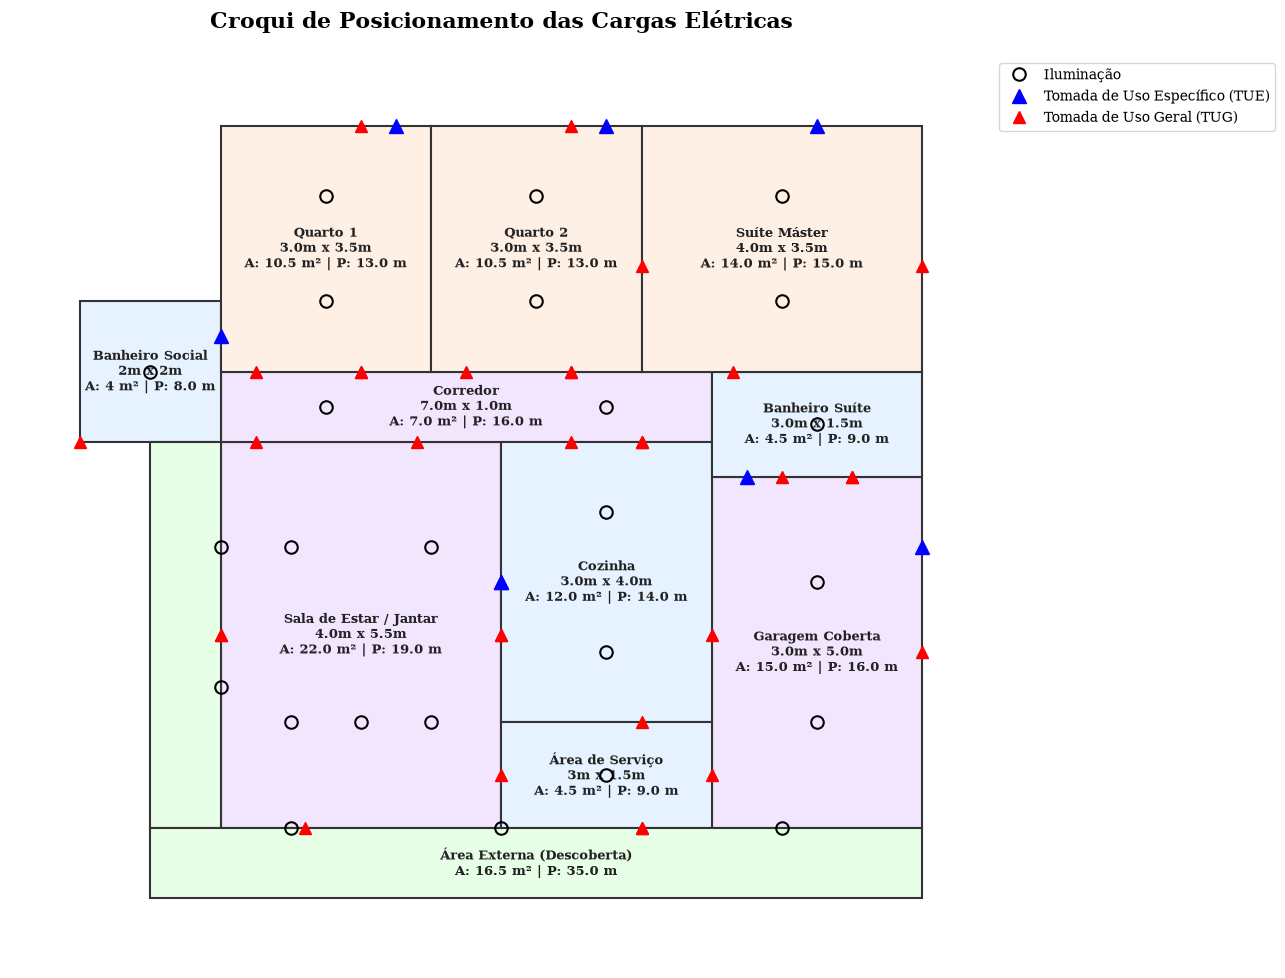

In [223]:
def plotar_planta_com_cargas(cargas):

    fig, ax = plt.subplots(figsize=(14, 10))
        
    # Formato: (x, y, largura, comprimento, Nome, Area, Perimetro, Cor)
    comodos = [
        # Setor Social / Acesso (Tons de Azul/Cinza)
        (0, 0, 4.0, 5.5, "Sala de Estar / Jantar", 22.0, 19.0, '#f2e6ff'),
        (7, 0, 3.0, 5.0, "Garagem Coberta", 15.0, 16.0, '#f2e6ff'),
        (0, 5.5, 7.0, 1.0, "Corredor", 7.0, 16.0, '#f2e6ff'),
        # x0, y0, x, y
        # Setor de Serviço / Molhado (Tons de Verde/Amarelo)
        (4, 1.5, 3.0, 4.0, "Cozinha", 12.0, 14.0, '#e6f2ff'),
        (4, 0, 3, 1.5, "Área de Serviço", 4.5, 9.0, '#e6f2ff'),
        (7, 5, 3.0, 1.5, "Banheiro Suíte", 4.5, 9.0, '#e6f2ff'),
        (-2, 5.5, 2, 2, "Banheiro Social", 4, 8.0, '#e6f2ff'),
        
        # Setor Íntimo (Tons de Laranja/Pêssego)
        (0, 6.5, 3.0, 3.5, "Quarto 1", 10.5, 13.0, '#fff0e6'),
        (3, 6.5, 3.0, 3.5, "Quarto 2", 10.5, 13.0, '#fff0e6'),
        (6, 6.5, 4.0, 3.5, "Suíte Máster", 14.0, 15.0, '#fff0e6'),
        
        # Área Externa Descoberta (dividida em duas partes para formar o L, mas com texto só em uma)
        (-1.0, 0, 1.0, 5.5, "", "", "", '#e6ffe6'),
        (-1.0, -1.0, 11.0, 1.0, "Área Externa (Descoberta)", 16.5, 35.0, '#e6ffe6')
    ]
    
    # Desenha cada cômodo
    for (x, y, largura, comprimento, nome, area, perimetro, cor) in comodos:
        retangulo = patches.Rectangle((x, y), largura, comprimento, 
                                      linewidth=1.5, edgecolor='#333333', facecolor=cor)
        ax.add_patch(retangulo)
        
        # Imprime o texto apenas se houver um nome definido para o bloco
        if nome != "":
            # Para cômodos normais ou áreas compostas, ajustamos a exibição do texto:
            if "Área Externa" in nome:
                texto_cota = f"{nome}\nA: {area} m² | P: {perimetro} m"
            else:
                texto_cota = f"{nome}\n{largura}m x {comprimento}m\nA: {area} m² | P: {perimetro} m"
            
            ax.text(x + largura/2, y + comprimento/2, texto_cota, 
                    ha='center', va='center', fontsize=9, weight='bold', color='#222222')

    # Plotagem das cargas
    for c in cargas:
        desc = c.descricao.lower()
        if "luz" in desc:
            # Círculos vazios para iluminação
            ax.plot(c.x, c.y, marker='o', markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.5, markersize=9, linestyle='None', zorder=5)
        elif "tue" in desc:
            ax.plot(c.x, c.y, marker='^', color='blue', markersize=10, linestyle='None', zorder=5)
        else:
            # TUGs (qualquer carga que não seja luz nem TUE)
            ax.plot(c.x, c.y, marker='^', color='red', markersize=8, linestyle='None', zorder=5)

    # 5. Configuração da Legenda
    legenda_luz = mlines.Line2D([], [], marker='o', markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.5, linestyle='None', markersize=9, label='Iluminação')
    legenda_tue = mlines.Line2D([], [], color='blue', marker='^', linestyle='None', markersize=10, label='Tomada de Uso Específico (TUE)')
    legenda_tug = mlines.Line2D([], [], color='red', marker='^', linestyle='None', markersize=8, label='Tomada de Uso Geral (TUG)')
    
    ax.legend(handles=[legenda_luz, legenda_tue, legenda_tug], loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

    # Configurações finais da plotagem
    ax.set_xlim(-3, 11)
    ax.set_ylim(-2, 11)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.title("Croqui de Posicionamento das Cargas Elétricas", fontsize=16, weight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Executando a função com as suas variáveis
plotar_planta_com_cargas(todas_cargas)

## Tabela geral de cargas instaladas

In [224]:
vetor_cargas = [
    (
        carga.descricao,
        carga.potencia_va,
        carga.x,
        carga.y,
        carga.z,
        carga.fp,
        carga.rendimento,
        carga.categoria
    )
    for carga in projeto_eletrico.cargas_posicionadas
]

# Organiza as cargas em uma tabela para facilitar a visualização
df_vetor_cargas = pd.DataFrame(
    vetor_cargas,
    columns=[
        "Descrição",
        "Potência (VA)",
        "x",
        "y",
        "z",
        "Fator de potência (fp)",
        "Rendimento",
        "Categoria"
    ],
)

demanda_maxima = 0.0
for carga in vetor_cargas:
    demanda_maxima += carga[1]

print("Potência nominal = "+str(demanda_maxima)+" VA")

df_vetor_cargas.loc[len(df_vetor_cargas)] = [
    "Demanda máxima (100% simultaneidade)",
    demanda_maxima,
    "x",
    "x",
    "x",
    "x",
    "x",
    "x"
]
df_vetor_cargas.index = [''] * len(df_vetor_cargas)

# Configura o Pandas para mostrar todas as linhas
pd.set_option('display.max_rows', None)

# (Opcional) Se quiser garantir que nenhuma coluna também seja ocultada:
pd.set_option('display.max_columns', None)

display(df_vetor_cargas)

Potência nominal = 28829.0 VA


,Descrição,Potência (VA),x,y,z,Fator de potência (fp),Rendimento,Categoria
,Ar Condicionado (TUE),1000.0,2.5,10.0,2.5,0.85,x,c
,Luz Teto 1,80.0,1.5,7.5,2.7,x,x,a
,Luz Teto 2,80.0,1.5,9.0,2.7,x,x,a
,TUG 1,100.0,2.0,10.0,0.3,x,x,a
,TUG 2,100.0,0.5,6.5,0.3,x,x,a
,TUG 3,100.0,2.0,6.5,0.3,x,x,a
,Ar Condicionado (TUE),1000.0,5.5,10.0,2.5,0.85,x,c
,Luz Teto 1,80.0,4.5,7.5,2.7,x,x,a
,Luz Teto 2,80.0,4.5,9.0,2.7,x,x,a
,TUG 1,100.0,5.0,10.0,0.3,x,x,a


# Etapa 2: Demanda provável e padrão Light

A soma de todas as cargas instaladas não representa a potência que provavelmente será usada ao mesmo tempo, então nesta etapa foi seguido o procedimento de demanda mostrado em aula e na RECON-BT. As cargas da residência foram separadas nas categorias C1, C2, C3, C5 e C6, aplicando os fatores correspondentes a cada grupo e comparando a carga de C1 calculada para o projeto com o valor mínimo residencial indicado pela concessionária.

Depois de calcular cada parcela, a demanda total foi obtida pela soma das demandas consideradas para os grupos usados na residência:

$$
D_{\mathrm{total}} = D_1 + D_2 + D_3 + D_4 + D_5 
$$

Esse valor é o que foi usado para escolher o padrão de fornecimento e para os cálculos do alimentador principal.


In [225]:
# Soma das cargas lançadas em C1 e C2 no projeto
potencias_por_categoria = {"a": 0.0, "b": 0.0, "c": 0.0, "d": 0.0, "e": 0.0}
for carga in vetor_cargas:
    cat = str(carga[7]).strip().lower()
    if cat in potencias_por_categoria:
        potencias_por_categoria[cat] += carga[1]

# C1, iluminação e tomadas
C1_declarada = potencias_por_categoria["a"] / 1000.0
C1_min_area = 0.030 * A_tot
C1 = max(C1_declarada, C1_min_area)

# Fatores progressivos residenciais de C1, por faixa de 1 kVA
fatores_C1 = [0.80, 0.75, 0.65, 0.60, 0.50, 0.45, 0.40, 0.35, 0.30, 0.27]
D1 = 0.0
restante = C1
for fd in fatores_C1:
    if restante <= 0:
        break
    parcela = min(1.0, restante)
    D1 += parcela * fd
    restante -= parcela

if restante > 0:
    D1 += restante * 0.24

# C2, aquecimento, com os dois chuveiros agrupados
C2 = (P_chuv1 + P_chuv2) / 1000.0
FD_C2 = 0.75  # dois aparelhos de aquecimento
D2 = C2 * FD_C2

# C3, condicionadores de ar, usando a conversão da RECON-BT
C3 = 2 * 0.584 + 0.877  # 2 x 9.000 BTU/h + 1 x 12.000 BTU/h
FD_C3 = 1.00            # 3 aparelhos
D3 = C3 * FD_C3

# C5, motobomba, com 0,575 kVA para o motor de 1/2 cv
C5 = 0.575
FD_C5 = 1.00
D5 = C5 * FD_C5

C6 = 0.0
D6 = 0.0

carga_instalada_recon_kva = C1 + C2 + C3 + C5 + C6
demanda_provavel_kva = D1 + D2 + D3 + D5 + D6

resumo_demanda = pd.DataFrame([
    ["C1, Iluminação e tomadas", C1, D1, "fatores progressivos"],
    ["C2, Aquecimento", C2, D2, "75% para 2 chuveiros"],
    ["C3, Condicionadores de ar", C3, D3, "100% para 3 aparelhos"],
    ["C5, Motor / motobomba", C5, D5, "100% para 1 motor"],
    ["C6, Cargas especiais", C6, D6, "não se aplica"],
], columns=["Categoria RECON", "Carga instalada (kVA)", "Demanda (kVA)", "Critério"])

display(resumo_demanda.round(4))
print(f"C1 declarada = {C1_declarada:.3f} kVA")
print(f"C1 mínima por área = 0,030 x {A_tot:.0f} = {C1_min_area:.3f} kVA")
print(f"Carga instalada pela base RECON = {carga_instalada_recon_kva:.3f} kVA")
print(f"Demanda provável total = {demanda_provavel_kva:.3f} kVA")
print("\nObservação: a soma RECON não coincide exatamente com a soma elétrica dos circuitos,")
print("pois a concessionária usa valores tabelados próprios para motores e ar-condicionado.")


,Categoria RECON,Carga instalada (kVA),Demanda (kVA),Critério
0,"C1, Iluminação e tomadas",11.960,5.5404,fatores progressivos
1,"C2, Aquecimento",13.000,9.7500,75% para 2 chuveiros
2,"C3, Condicionadores de ar",2.045,2.0450,100% para 3 aparelhos
3,"C5, Motor / motobomba",0.575,0.5750,100% para 1 motor
4,"C6, Cargas especiais",0.000,0.0000,não se aplica


C1 declarada = 11.960 kVA
C1 mínima por área = 0,030 x 103 = 3.090 kVA
Carga instalada pela base RECON = 27.580 kVA
Demanda provável total = 17.910 kVA

Observação: a soma RECON não coincide exatamente com a soma elétrica dos circuitos,
pois a concessionária usa valores tabelados próprios para motores e ar-condicionado.


## Determinação do padrão de atendimento da Light

Com a demanda provável já calculada, o valor foi comparado com as faixas da Tabela 7.3 da RECON-BT 2026. Para o sistema 220/127 V, a demanda encontrada ficou na faixa T2, que atende valores acima de 15 kVA até 24 kVA e leva à adoção de proteção geral tripolar de 63 A, com ramal de entrada em cobre de 16 mm².


In [226]:
def determinar_padrao_light_tabela_73(d):
    # Faixas principais da Tabela 7.3 para 220/127 V
    if d <= 5:
        dados = ("UM1", "127 V, 1F+N", "40 A, 1P", "2 x 10 mm²", "10 mm²", '1"')
    elif d <= 8:
        dados = ("UB1", "220/127 V, 2F+N", "40 A, 2P", "3 x 10 mm²", "10 mm²", '2"')
    elif d <= 13:
        dados = ("UB2", "220/127 V, 2F+N", "63 A, 2P", "3 x 16 mm²", "16 mm²", '2"')
    elif d <= 15:
        dados = ("T1", "220/127 V, 3F+N", "40 A, 3P", "4 x 10 mm²", "10 mm²", '2"')
    elif d <= 24:
        dados = ("T2", "220/127 V, 3F+N", "63 A, 3P", "4 x 16 mm²", "16 mm²", '2"')
    elif d <= 30:
        dados = ("T3", "220/127 V, 3F+N", "80 A, 3P", "4 x 25 mm²", "16 mm²", '2"')
    elif d <= 38:
        dados = ("T4", "220/127 V, 3F+N", "100 A, 3P", "4 x 35 mm²", "16 mm²", '2"')
    elif d <= 47:
        dados = ("T5", "220/127 V, 3F+N", "125 A, 3P", "4 x 50 mm²", "25 mm²", '3"')
    elif d <= 57:
        dados = ("T6", "220/127 V, 3F+N", "150 A, 3P", "4 x 70 mm²", "35 mm²", '3"')
    elif d <= 66:
        dados = ("T7", "220/127 V, 3F+N", "175 A, 3P", "4 x 95 mm²", "50 mm²", '3"')
    elif d <= 76:
        dados = ("T8", "220/127 V, 3F+N", "200 A, 3P", "4 x 95 mm²", "50 mm²", '3"')
    else:
        dados = ("TI", "consulta à Light", "medição indireta", "dimensionamento específico", "-", "-")

    return {
        "Categoria": dados[0], "Tensão": dados[1], "Proteção geral": dados[2],
        "Ramal de entrada": dados[3], "PE / aterramento": dados[4],
        "Eletroduto de entrada aéreo": dados[5]
    }

padrao_light = determinar_padrao_light_tabela_73(demanda_provavel_kva)
display(pd.DataFrame([{"Demanda (kVA)": demanda_provavel_kva, **padrao_light}]).round(3))


,Demanda (kVA),Categoria,Tensão,Proteção geral,Ramal de entrada,PE / aterramento,Eletroduto de entrada aéreo
0,17.91,T2,"220/127 V, 3F+N","63 A, 3P",4 x 16 mm²,16 mm²,"2"""


# Etapa 3: Circuitos, correntes de projeto e baricentro

A divisão dos circuitos foi feita separando iluminação, tomadas de uso geral e cargas específicas, porque essa organização deixa o quadro mais fácil de entender e também acompanha o procedimento usado nas aulas. Os circuitos de cozinha e área de serviço ficaram separados dos demais pontos de tomadas e os chuveiros, a motobomba, o forno de microondas, a airfryer e os condicionadores de ar foram mantidos em circuitos próprios, como pedido no enunciado.

Para cada circuito, a corrente de projeto foi obtida a partir da potência aparente total ligada naquele circuito e da sua tensão de alimentação:

$$
I_B = \frac{S}{V}
$$

Com essas correntes foi possível continuar o dimensionamento dos condutores, dos disjuntores e dos eletrodutos nas etapas seguintes.


In [227]:
especificacoes_circuitos = [
    ("LUZ-LAZER", "Q1-Q2-SUI-SALA", "ILUM", V_pn, 0.0,
     [carga_q1_l1,
      carga_q1_l2,
      carga_q2_l1,
      carga_q2_l2,
      carga_sui_l1,
      carga_sui_l2,
      carga_sala_l1,
      carga_sala_l2,
      carga_sala_l3,
      carga_sala_l4,
      carga_sala_l5]),
    ("LUZ-COMUM", "BASOC-BASUI-CORR-COZ-GARA-ASERV-EXT", "ILUM", V_pn, 0.0,
     [carga_bs_l1,
      carga_bsui_l1,
      carga_corr_l1,
      carga_corr_l2,
      carga_coz_l1,
      carga_coz_l2,
      carga_gara_l1,
      carga_gara_l2,
      carga_serv_l1,
      carga_ext_l1,
      carga_ext_l2,
      carga_ext_l3,
      carga_ext_l4,
      carga_ext_l5]),
    ("TUG-COMUM", "SALA-CORR-GARA-EXT", "TUG", V_pn, 0.0,
     [carga_sala_t1,
      carga_sala_t2,
      carga_sala_t3,
      carga_sala_t4,
      carga_corr_t1,
      carga_corr_t2,
      carga_corr_t3,
      carga_corr_t4,
      carga_gara_t1,
      carga_gara_t2,
      carga_gara_t3,
      carga_gara_t4,
      carga_ext_t1,
      carga_ext_t2]),
    ("TUG-LAZER", "Q1-Q2-SUI", "TUG", V_pn, 0.0,
     [carga_q1_t1,
      carga_q1_t2,
      carga_q1_t3,
      carga_q2_t1,
      carga_q2_t2,
      carga_q2_t3,
      carga_sui_t1,
      carga_sui_t2,
      carga_sui_t3]),
    ("TUG-COZ", "COZ", "TUG", V_pn, 0.0,
     [carga_coz_t1,
      carga_coz_t2,
      carga_coz_t3,
      carga_coz_t4]),
    ("TUG-SERV", "SERV", "TUG", V_pn, 0.0,
     [carga_serv_t1,
      carga_serv_t2,
      carga_serv_t3]),
    ("TUG-BAN", "BASOC-BASUI", "TUG", V_pn, 0.0,
     [carga_bs_t1,
      carga_bsui_t1]),
    ("CHSOCI", "BASOC", "TUE", V_pp, 0.0, [carga_bs_ch]),
    ("CHSUI", "BASUI", "TUE", V_pp, 0.0, [carga_bsui_ch]),
    ("MOTBOB", "GARA", "TUE", V_pp, 0.0, [carga_motobomba]),
    ("MIOND", "COZ", "TUE", V_pn, 0.0, [carga_forno]),
    ("AIR", "COZ", "TUE", V_pn, 0.0, [carga_air]),
    ("ARCO1", "Q1", "TUE", V_pp, 0.0, [carga_q1_ac]),
    ("ARCO2", "Q2", "TUE", V_pp, 0.0, [carga_q2_ac]),
    ("ARCOSUI", "SUI", "TUE", V_pp, 0.0, [carga_sui_ac])
    ]

circuitos_projeto = []
resumo_circuitos = []
for nome, descricao, tipo, tensao, secao, cargas in especificacoes_circuitos:
    circuito = Circuito(nome, nome, tipo, 0, tensao, 0, secao)
    for carga in cargas:
        circuito.adicionar_carga(carga)
    demanda = circuito.calcular_demanda_total()
    corrente = circuito.calcular_corrente_total()
    secao_calculada = circuito.calcular_secao_minima()
    circuitos_projeto.append(circuito)
    resumo_circuitos.append({
        "Circuito": nome,
        "Cômodos": descricao,
        "Tipo": tipo,
        "Potência (VA)": demanda,
        "Tensão (V)": tensao,
        "Corrente (A)": round(corrente, 2),
        "Seção mínima estimada (mm²)": secao_calculada
    })

# Tabela para conferir, por circuito, carga acumulada, corrente estimada e seção calculada.
df_resumo_circuitos = pd.DataFrame(resumo_circuitos)

# Calculando a potência total do projeto para conferência
df_resumo_circuitos["Potência (VA)"] = df_resumo_circuitos["Potência (VA)"].astype(float)
potencia_total_projeto = df_resumo_circuitos["Potência (VA)"].sum()
print(f"\nPotência total do projeto (VA): {potencia_total_projeto:.2f} VA")

display(df_resumo_circuitos)


Potência total do projeto (VA): 28829.00 VA


,Circuito,Cômodos,Tipo,Potência (VA),Tensão (V),Corrente (A),Seção mínima estimada (mm²)
0,LUZ-LAZER,Q1-Q2-SUI-SALA,ILUM,880.0,127,6.93,1.5
1,LUZ-COMUM,BASOC-BASUI-CORR-COZ-GARA-ASERV-EXT,ILUM,980.0,127,7.72,1.5
2,TUG-COMUM,SALA-CORR-GARA-EXT,TUG,1400.0,127,11.02,2.5
3,TUG-LAZER,Q1-Q2-SUI,TUG,900.0,127,7.09,2.5
4,TUG-COZ,COZ,TUG,1900.0,127,14.96,2.5
5,TUG-SERV,SERV,TUG,1800.0,127,14.17,2.5
6,TUG-BAN,BASOC-BASUI,TUG,1200.0,127,9.45,2.5
7,CHSOCI,BASOC,TUE,5500.0,220,25.00,4.0
8,CHSUI,BASUI,TUE,7500.0,220,34.09,6.0
9,MOTBOB,GARA,TUE,575.0,220,2.61,2.5


## Baricentro elétrico e posição do QDG

Para escolher uma região adequada para o quadro de distribuição, foi calculado o centro elétrico da instalação usando a potência aparente de cada carga como peso, de forma que as cargas maiores tenham mais influência na posição encontrada. As coordenadas foram calculadas pelas expressões abaixo:

$$
\begin{aligned}
\bar{X} &= \frac{\sum S_i x_i}{\sum S_i} \\[6pt]
\bar{Y} &= \frac{\sum S_i y_i}{\sum S_i}
\end{aligned}
$$

O ponto calculado foi usado como referência para posicionar o QDG e, depois disso, a posição foi ajustada para um local próximo no corredor, mantendo o quadro acessível e compatível com a planta da residência.


In [228]:
x_qdc, y_qdc = projeto_eletrico.calcular_baricentro()

# Posiciona o QDG no corredor, muito próximo do baricentro matemático
x_qdg = 4.70
y_qdg = 5.50
dist_baricentro_qdg = math.hypot(x_qdg - x_qdc, y_qdg - y_qdc)

print(f"Baricentro elétrico: X = {x_qdc:.2f} m, Y = {y_qdc:.2f} m")
print(f"Posição física adotada do QDG: X = {x_qdg:.2f} m, Y = {y_qdg:.2f} m")
print(f"Deslocamento necessário por compatibilização arquitetônica: {dist_baricentro_qdg:.2f} m")

# Influências externas mais relevantes ao projeto
df_ip = pd.DataFrame([
    ["Banheiro, volume 0", "imersão", "IPX7", "sem tomada"],
    ["Banheiro, volume 1", "respingos", "IPX4", "equipamentos permitidos pela seção 9.1"],
    ["Banheiro, volume 2", "respingos", "IPX3", "adota-se luminária IP44"],
    ["Banheiro, volume 3", "umidade", "IPX1", "TUG apenas neste volume, com IP44 + DR no projeto"],
    ["Cozinha / área de serviço", "umidade e respingos localizados", "conforme posição", "adota-se IP44 próximo a pia/tanque"],
    ["Garagem coberta", "local sujeito a umidade", "conforme influência AD", "adota-se IP44"],
    ["Área externa descoberta", "chuva / projeções d'água", "IPX4 para AD4", "adota-se IP55"],
], columns=["Local", "Influência", "Mínimo / condição NBR 5410", "Especificação de projeto"])

display(df_ip)


Baricentro elétrico: X = 4.72 m, Y = 5.48 m
Posição física adotada do QDG: X = 4.70 m, Y = 5.50 m
Deslocamento necessário por compatibilização arquitetônica: 0.03 m


,Local,Influência,Mínimo / condição NBR 5410,Especificação de projeto
0,"Banheiro, volume 0",imersão,IPX7,sem tomada
1,"Banheiro, volume 1",respingos,IPX4,equipamentos permitidos pela seção 9.1
2,"Banheiro, volume 2",respingos,IPX3,adota-se luminária IP44
3,"Banheiro, volume 3",umidade,IPX1,"TUG apenas neste volume, com IP44 + DR no projeto"
4,Cozinha / área de serviço,umidade e respingos localizados,conforme posição,adota-se IP44 próximo a pia/tanque
5,Garagem coberta,local sujeito a umidade,conforme influência AD,adota-se IP44
6,Área externa descoberta,chuva / projeções d'água,IPX4 para AD4,adota-se IP55


# Etapa 4: Dimensionamento de condutores e eletrodutos

Nesta etapa foram dimensionados os condutores dos circuitos usando cabos de cobre com isolação de PVC para 70 °C instalados em eletroduto embutido em alvenaria, seguindo o método de referência B1 trabalhado nas aulas. Para chegar à seção adotada em cada circuito, foram considerados a seção mínima, a capacidade de condução de corrente com os fatores de correção, a queda de tensão e, depois disso, também foram definidos o neutro, o condutor de proteção, o eletroduto e o disjuntor correspondente.


## Aplicação dos fatores de correção

A temperatura ambiente considerada foi de 30 °C, então o fator de correção por temperatura ficou igual a 1,00. Para o agrupamento, foi usado um fator diferente conforme a quantidade de circuitos que percorrem juntos cada trecho, considerando três circuitos nos trechos gerais, dois nos trechos da cozinha e da área de serviço e apenas um nos circuitos dedicados que seguem sozinhos.

$$
F_{ct} = 1{,}00
$$

A corrente usada para consultar a capacidade dos cabos foi obtida corrigindo a corrente de projeto pelos fatores adotados:

$$
I'_B = \frac{I_B}{F_{ct}F_{ca}}
$$

Dessa forma, cada circuito foi verificado com o fator de agrupamento correspondente ao caminho considerado no projeto, em vez de usar o mesmo valor para todos os trechos.


In [229]:
# Lista para armazenar os dados de dimensionamento de cada circuito
dados_tabela_dimensionamento = []

# Circuito 1
circuito_1 = circuitos_projeto[0]
res_c1 = circuito_1.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=3)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_1.nome,
    "Tipo": circuito_1.tipo,
    "Corrente Original (A)": res_c1["corrente_projeto"],
    "Fct (Temp)": res_c1["fct"],
    "Fca (Agrup)": res_c1["fca"],
    "Corrente Corrigida (A)": res_c1["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_1.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c1["secao_final"]
})

# Circuito 2
circuito_2 = circuitos_projeto[1]
res_c2 = circuito_2.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=3)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_2.nome,
    "Tipo": circuito_2.tipo,
    "Corrente Original (A)": res_c2["corrente_projeto"],
    "Fct (Temp)": res_c2["fct"],
    "Fca (Agrup)": res_c2["fca"],
    "Corrente Corrigida (A)": res_c2["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_2.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c2["secao_final"]
})

# Circuito 3
circuito_3 = circuitos_projeto[2]
res_c3 = circuito_3.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=3)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_3.nome,
    "Tipo": circuito_3.tipo,
    "Corrente Original (A)": res_c3["corrente_projeto"],
    "Fct (Temp)": res_c3["fct"],
    "Fca (Agrup)": res_c3["fca"],
    "Corrente Corrigida (A)": res_c3["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_3.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c3["secao_final"]
})

# Circuito 4
circuito_4 = circuitos_projeto[3]
res_c4 = circuito_4.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=3)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_4.nome,
    "Tipo": circuito_4.tipo,
    "Corrente Original (A)": res_c4["corrente_projeto"],
    "Fct (Temp)": res_c4["fct"],
    "Fca (Agrup)": res_c4["fca"],
    "Corrente Corrigida (A)": res_c4["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_4.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c4["secao_final"]
})

# Circuito 5
circuito_5 = circuitos_projeto[4]
res_c5 = circuito_5.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=2)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_5.nome,
    "Tipo": circuito_5.tipo,
    "Corrente Original (A)": res_c5["corrente_projeto"],
    "Fct (Temp)": res_c5["fct"],
    "Fca (Agrup)": res_c5["fca"],
    "Corrente Corrigida (A)": res_c5["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_5.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c5["secao_final"]
})

# Circuito 6
circuito_6 = circuitos_projeto[5]
res_c6 = circuito_6.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=2)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_6.nome,
    "Tipo": circuito_6.tipo,
    "Corrente Original (A)": res_c6["corrente_projeto"],
    "Fct (Temp)": res_c6["fct"],
    "Fca (Agrup)": res_c6["fca"],
    "Corrente Corrigida (A)": res_c6["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_6.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c6["secao_final"]
})

# Circuito 7
circuito_7 = circuitos_projeto[6]
res_c7 = circuito_7.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=2)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_7.nome,
    "Tipo": circuito_7.tipo,
    "Corrente Original (A)": res_c7["corrente_projeto"],
    "Fct (Temp)": res_c7["fct"],
    "Fca (Agrup)": res_c7["fca"],
    "Corrente Corrigida (A)": res_c7["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_7.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c7["secao_final"]
})

# Circuito 8
circuito_8 = circuitos_projeto[7]
res_c8 = circuito_8.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_8.nome,
    "Tipo": circuito_8.tipo,
    "Corrente Original (A)": res_c8["corrente_projeto"],
    "Fct (Temp)": res_c8["fct"],
    "Fca (Agrup)": res_c8["fca"],
    "Corrente Corrigida (A)": res_c8["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_8.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c8["secao_final"]
})

# Circuito 9
circuito_9 = circuitos_projeto[8]
res_c9 = circuito_9.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_9.nome,
    "Tipo": circuito_9.tipo,
    "Corrente Original (A)": res_c9["corrente_projeto"],
    "Fct (Temp)": res_c9["fct"],
    "Fca (Agrup)": res_c9["fca"],
    "Corrente Corrigida (A)": res_c9["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_9.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c9["secao_final"]
})

# Circuito 10
circuito_10 = circuitos_projeto[9]
res_c10 = circuito_10.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_10.nome,
    "Tipo": circuito_10.tipo,
    "Corrente Original (A)": res_c10["corrente_projeto"],
    "Fct (Temp)": res_c10["fct"],
    "Fca (Agrup)": res_c10["fca"],
    "Corrente Corrigida (A)": res_c10["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_10.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c10["secao_final"]
})

# Circuito 11
circuito_11 = circuitos_projeto[10]
res_c11 = circuito_11.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=2)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_11.nome,
    "Tipo": circuito_11.tipo,
    "Corrente Original (A)": res_c11["corrente_projeto"],
    "Fct (Temp)": res_c11["fct"],
    "Fca (Agrup)": res_c11["fca"],
    "Corrente Corrigida (A)": res_c11["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_11.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c11["secao_final"]
})

# Circuito 12
circuito_12 = circuitos_projeto[11]
res_c12 = circuito_12.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=2)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_12.nome,
    "Tipo": circuito_12.tipo,
    "Corrente Original (A)": res_c12["corrente_projeto"],
    "Fct (Temp)": res_c12["fct"],
    "Fca (Agrup)": res_c12["fca"],
    "Corrente Corrigida (A)": res_c12["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_12.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c12["secao_final"]
})

# Circuito 13
circuito_13 = circuitos_projeto[12]
res_c13 = circuito_13.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_13.nome,
    "Tipo": circuito_13.tipo,
    "Corrente Original (A)": res_c13["corrente_projeto"],
    "Fct (Temp)": res_c13["fct"],
    "Fca (Agrup)": res_c13["fca"],
    "Corrente Corrigida (A)": res_c13["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_13.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c13["secao_final"]
})

# Circuito 14
circuito_14 = circuitos_projeto[13]
res_c14 = circuito_14.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_14.nome,
    "Tipo": circuito_14.tipo,
    "Corrente Original (A)": res_c14["corrente_projeto"],
    "Fct (Temp)": res_c14["fct"],
    "Fca (Agrup)": res_c14["fca"],
    "Corrente Corrigida (A)": res_c14["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_14.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c14["secao_final"]
})

# Circuito 15
circuito_15 = circuitos_projeto[14]
res_c15 = circuito_15.calcular_secao_dimensionada(temp_ambiente=30, agrupamento=1)
dados_tabela_dimensionamento.append({
    "Circuito": circuito_15.nome,
    "Tipo": circuito_15.tipo,
    "Corrente Original (A)": res_c15["corrente_projeto"],
    "Fct (Temp)": res_c15["fct"],
    "Fca (Agrup)": res_c15["fca"],
    "Corrente Corrigida (A)": res_c15["corrente_corrigida"],
    "Seção Mínima (mm²)": circuito_15.obter_secao_minima_normativa(),
    "Seção Dimensionada (mm²)": res_c15["secao_final"]
})

df_dimensionamento_circuitos = pd.DataFrame(dados_tabela_dimensionamento)

# Ocultando o índice numérico padrão do Pandas para uma visualização mais limpa
df_dimensionamento_circuitos.index = [''] * len(df_dimensionamento_circuitos)

print("--- TABELA RESUMO: DIMENSIONAMENTO DE CONDUTORES ---")
display(df_dimensionamento_circuitos)

--- TABELA RESUMO: DIMENSIONAMENTO DE CONDUTORES ---


,Circuito,Tipo,Corrente Original (A),Fct (Temp),Fca (Agrup),Corrente Corrigida (A),Seção Mínima (mm²),Seção Dimensionada (mm²)
,LUZ-LAZER,ILUM,6.93,1.0,0.7,9.90,1.5,1.5
,LUZ-COMUM,ILUM,7.72,1.0,0.7,11.02,1.5,1.5
,TUG-COMUM,TUG,11.02,1.0,0.7,15.75,2.5,2.5
,TUG-LAZER,TUG,7.09,1.0,0.7,10.12,2.5,2.5
,TUG-COZ,TUG,14.96,1.0,0.8,18.70,2.5,2.5
,TUG-SERV,TUG,14.17,1.0,0.8,17.72,2.5,2.5
,TUG-BAN,TUG,9.45,1.0,0.8,11.81,2.5,2.5
,CHSOCI,TUE,25.00,1.0,1.0,25.00,2.5,4.0
,CHSUI,TUE,34.09,1.0,1.0,34.09,2.5,6.0
,MOTBOB,TUE,2.61,1.0,1.0,2.61,2.5,2.5


## Queda de tensão e limite global

A queda de tensão foi calculada separando o alimentador principal dos circuitos terminais, porque a soma das duas parcelas precisa permanecer dentro do limite global usado para a instalação. Para os circuitos terminais com dois condutores carregados, tanto em 127 V com fase e neutro quanto em 220 V com duas fases, foi usada a expressão:

$$
\Delta V(\%) =
\frac{200\,\rho\,L\,I_B}{S\,V}
$$

Para o alimentador trifásico, foi usada a expressão correspondente ao sistema de três fases:

$$
\Delta V_{\mathrm{alim}}(\%) =
\frac{100\sqrt{3}\,\rho\,L\,I_B}{S\,V_{LL}}
$$

Primeiro foi calculada a queda de tensão do alimentador e o valor restante até 4% foi usado como limite para cada circuito terminal, assim a verificação considera o caminho completo desde a entrada até a carga e não apenas o circuito final.


In [230]:
# Dimensionamento final: seção mínima + ampacidade + queda de tensão global
rho_cu = 0.01786
Fct_final = 1.00

comprimentos_etapa4 = {
    "LUZ-LAZER": 30.70, "LUZ-COMUM": 35.80, "TUG-COMUM": 42.85,
    "TUG-LAZER": 26.10, "TUG-COZ": 10.35, "TUG-SERV": 7.90,
    "TUG-BAN": 15.65, "CHSOCI": 8.60, "CHSUI": L_crit,
    "MOTBOB": 6.10, "MIOND": 3.90, "AIR": 3.90,
    "ARCO1": 9.60, "ARCO2": 6.60, "ARCOSUI": 9.60,
}

ampacidade_B1_2cc = {
    1.5: 17.5, 2.5: 24.0, 4.0: 32.0, 6.0: 41.0,
    10.0: 57.0, 16.0: 76.0, 25.0: 101.0
}
secoes_comerciais = [1.5, 2.5, 4.0, 6.0, 10.0, 16.0, 25.0]

# O Fca calculado anteriormente é reaproveitado circuito a circuito
fca_por_circuito = {
    row["Circuito"]: float(row["Fca (Agrup)"])
    for _, row in df_dimensionamento_circuitos.reset_index(drop=True).iterrows()
}

# Primeiro é calculada a parcela de queda do alimentador T2 (16 mm²)
I_B_alim_pre = demanda_provavel_kva * 1000 / (math.sqrt(3) * V_pp)
dv_alim_pre = 100 * math.sqrt(3) * rho_cu * L_alim * I_B_alim_pre / (16.0 * V_pp)
delta_v_term_adm = 4.0 - dv_alim_pre

def queda_v_terminal_pct(Ib, Lm, Smm2, V):
    return 200 * rho_cu * Lm * Ib / (Smm2 * V)

def dimensionar_terminal_corrigido(circuito):
    Ib = circuito.calcular_corrente_total()
    Smin = circuito.obter_secao_minima_normativa()
    Fca = fca_por_circuito[circuito.nome]

    S_amp = None
    for S, Iz0 in ampacidade_B1_2cc.items():
        if S >= Smin and Ib <= Iz0 * Fct_final * Fca:
            S_amp = S
            break

    Lm = float(comprimentos_etapa4[circuito.nome])
    S_final = None
    for S in secoes_comerciais:
        if S < S_amp:
            continue
        if queda_v_terminal_pct(Ib, Lm, S, circuito.tensao) <= delta_v_term_adm:
            S_final = S
            break

    if S_final is None:
        raise ValueError(f"Não foi encontrada seção comercial para {circuito.nome}.")

    dv_final = queda_v_terminal_pct(Ib, Lm, S_final, circuito.tensao)
    Iz_final = ampacidade_B1_2cc[S_final] * Fct_final * Fca

    return {
        "Circuito": circuito.nome, "Tipo": circuito.tipo, "Tensão (V)": circuito.tensao,
        "L verificação (m)": Lm, "IB (A)": Ib, "Fct": Fct_final, "Fca": Fca,
        "Seção mínima (mm²)": Smin, "Seção ampacidade (mm²)": S_amp,
        "Iz' (A)": Iz_final, "Seção final (mm²)": S_final,
        "ΔV terminal (%)": dv_final, "ΔV global (%)": dv_alim_pre + dv_final,
        "Atende ΔV global": (dv_alim_pre + dv_final) <= 4.0
    }

df_etapa4_corrigido = pd.DataFrame(
    [dimensionar_terminal_corrigido(c) for c in circuitos_projeto]
)

print(f"Queda no alimentador = {dv_alim_pre:.3f}%")
print(f"Saldo máximo para o circuito terminal = {delta_v_term_adm:.3f}%")
display(df_etapa4_corrigido.round(3))


Queda no alimentador = 1.033%
Saldo máximo para o circuito terminal = 2.967%


,Circuito,Tipo,Tensão (V),L verificação (m),IB (A),Fct,Fca,Seção mínima (mm²),Seção ampacidade (mm²),Iz' (A),Seção final (mm²),ΔV terminal (%),ΔV global (%),Atende ΔV global
0,LUZ-LAZER,ILUM,127,30.70,6.929,1.0,0.7,1.5,1.5,16.8,2.5,2.393,3.426,True
1,LUZ-COMUM,ILUM,127,35.80,7.717,1.0,0.7,1.5,1.5,22.4,4.0,1.942,2.975,True
2,TUG-COMUM,TUG,127,42.85,11.024,1.0,0.7,2.5,2.5,28.7,6.0,2.214,3.247,True
3,TUG-LAZER,TUG,127,26.10,7.087,1.0,0.7,2.5,2.5,16.8,2.5,2.081,3.114,True
4,TUG-COZ,TUG,127,10.35,14.961,1.0,0.8,2.5,2.5,19.2,2.5,1.742,2.775,True
5,TUG-SERV,TUG,127,7.90,14.173,1.0,0.8,2.5,2.5,19.2,2.5,1.260,2.292,True
6,TUG-BAN,TUG,127,15.65,9.449,1.0,0.8,2.5,2.5,19.2,2.5,1.664,2.696,True
7,CHSOCI,TUE,220,8.60,25.000,1.0,1.0,2.5,4.0,32.0,4.0,0.873,1.905,True
8,CHSUI,TUE,220,18.00,34.091,1.0,1.0,2.5,6.0,41.0,6.0,1.661,2.693,True
9,MOTBOB,TUE,220,6.10,2.614,1.0,1.0,2.5,2.5,24.0,2.5,0.104,1.136,True


## Condutor neutro e condutor de proteção

Nos circuitos de 127 V, o neutro foi mantido com a mesma seção do condutor de fase, enquanto nos circuitos de 220 V alimentados por duas fases não foi necessário levar um neutro até a carga. Como todas as seções dos circuitos terminais ficaram até 16 mm², o condutor de proteção foi adotado com a mesma seção do condutor de fase.

$$
S_N = S_F \qquad \text{para os circuitos de 127 V}
$$

$$
S_{PE} = S_F \qquad \text{para } S_F \leq 16\ \mathrm{mm^2}
$$

Esse critério foi aplicado circuito por circuito na tabela de condutores apresentada a seguir.


In [231]:
# Em 127 V temos F+N+PE, enquanto em 220 V temos F+F+PE.
linhas_condutores = []
for circuito in circuitos_projeto:
    d = df_etapa4_corrigido.loc[df_etapa4_corrigido["Circuito"] == circuito.nome].iloc[0]
    Sfase = float(d["Seção final (mm²)"])
    eh_220 = circuito.tensao == 220

    Sneutro = 0.0 if eh_220 else Sfase
    num_fases = 2 if eh_220 else 1
    ativos = "F1/F2" if eh_220 else "F/N"
    SPE = circuito.calcular_secao_pe(Sfase)

    linhas_condutores.append({
        "Circuito": circuito.nome,
        "Alimentação": ativos,
        "IB (A)": d["IB (A)"],
        "Fase(s) (mm²)": Sfase,
        "Neutro (mm²)": Sneutro,
        "PE (mm²)": SPE,
        "ΔV terminal (%)": d["ΔV terminal (%)"],
        "ΔV global (%)": d["ΔV global (%)"],
        "Fct": d["Fct"],
        "Fca": d["Fca"],
    })

df_condutores_corrigido = pd.DataFrame(linhas_condutores)
print("--- QUADRO DE CONDUTORES ---")
display(df_condutores_corrigido)

--- QUADRO DE CONDUTORES ---


,Circuito,Alimentação,IB (A),Fase(s) (mm²),Neutro (mm²),PE (mm²),ΔV terminal (%),ΔV global (%),Fct,Fca
0,LUZ-LAZER,F/N,6.929134,2.5,2.5,2.5,2.393233,3.425903,1.0,0.7
1,LUZ-COMUM,F/N,7.716535,4.0,4.0,4.0,1.942465,2.975134,1.0,0.7
2,TUG-COMUM,F/N,11.023622,6.0,6.0,6.0,2.214275,3.246945,1.0,0.7
3,TUG-LAZER,F/N,7.086614,2.5,2.5,2.5,2.080880,3.113550,1.0,0.7
4,TUG-COZ,F/N,14.960630,2.5,2.5,2.5,1.742039,2.774709,1.0,0.8
5,TUG-SERV,F/N,14.173228,2.5,2.5,2.5,1.259690,2.292359,1.0,0.8
6,TUG-BAN,F/N,9.448819,2.5,2.5,2.5,1.663641,2.696311,1.0,0.8
7,CHSOCI,F1/F2,25.000000,4.0,0.0,4.0,0.872705,1.905374,1.0,1.0
8,CHSUI,F1/F2,34.090909,6.0,0.0,6.0,1.660537,2.693207,1.0,1.0
9,MOTBOB,F1/F2,2.613636,2.5,0.0,2.5,0.103544,1.136213,1.0,1.0


## Dimensionamento dos eletrodutos

Depois de definir as seções dos condutores, foi calculada a ocupação dos eletrodutos usando a área externa aproximada dos cabos, já que a ocupação física depende do diâmetro do cabo completo e não apenas da área de cobre. Foram considerados os limites de 53% para um condutor, 31% para dois condutores e 40% para três ou mais condutores, escolhendo em cada caso o primeiro eletroduto comercial que atendesse ao limite de ocupação.


In [232]:
# Nos circuitos de 220 V com duas fases não existe neutro no eletroduto.
dados_eletrodutos_corrigidos = []
for circuito in circuitos_projeto:
    d = df_condutores_corrigido.loc[df_condutores_corrigido["Circuito"] == circuito.nome].iloc[0]
    Sfase = float(d["Fase(s) (mm²)"])
    Sneutro = float(d["Neutro (mm²)"])
    SPE = float(d["PE (mm²)"])
    num_fases = 2 if circuito.tensao == 220 else 1

    res = circuito.calcular_eletroduto(
        secao_fase=Sfase, secao_neutro=Sneutro, secao_pe=SPE, num_fases=num_fases
    )
    dados_eletrodutos_corrigidos.append({
        "Circuito": circuito.nome,
        "Tensão (V)": circuito.tensao,
        "Condutores": f"{num_fases}F + " + ("N + " if Sneutro > 0 else "") + "PE",
        "Seções F/N/PE (mm²)": f"{Sfase:g}/{Sneutro:g}/{SPE:g}",
        "Eletroduto PVC": res["eletroduto"],
        "Ocupação real (%)": res["taxa_real_pct"],
        "Limite (%)": res["limite_norma_pct"],
    })

df_eletrodutos_corrigido = pd.DataFrame(dados_eletrodutos_corrigidos)

# Alimentador com 4 x 16 mm² (3F+N), PE de 16 mm² e PVC de 32 mm.
area_cabos = {1.5:8.0,2.5:11.0,4.0:14.5,6.0:18.1,10.0:28.3,16.0:40.7,25.0:60.8}
area_feeder = 5*area_cabos[16.0]  # 3F + N + PE
ocup_feeder = 100*area_feeder/530.0

print("--- ELETRODUTOS DOS CIRCUITOS TERMINAIS ---")
display(df_eletrodutos_corrigido)
print(f"\nAlimentador interno da medição até o QDG, 4 x 16 mm² + PE 16 mm² em eletroduto PVC 32 mm, com ocupação aproximada de {ocup_feeder:.1f}%.")
print("No padrão de entrada Light T2 foi considerado eletroduto aéreo de 2\", enquanto o trecho interno da medição até o QDG foi dimensionado separadamente.")


--- ELETRODUTOS DOS CIRCUITOS TERMINAIS ---


,Circuito,Tensão (V),Condutores,Seções F/N/PE (mm²),Eletroduto PVC,Ocupação real (%),Limite (%)
0,LUZ-LAZER,127,1F + N + PE,2.5/2.5/2.5,"16 mm (1/2"")",29.2,40
1,LUZ-COMUM,127,1F + N + PE,4/4/4,"16 mm (1/2"")",38.5,40
2,TUG-COMUM,127,1F + N + PE,6/6/6,"20 mm (3/4"")",30.0,40
3,TUG-LAZER,127,1F + N + PE,2.5/2.5/2.5,"16 mm (1/2"")",29.2,40
4,TUG-COZ,127,1F + N + PE,2.5/2.5/2.5,"16 mm (1/2"")",29.2,40
5,TUG-SERV,127,1F + N + PE,2.5/2.5/2.5,"16 mm (1/2"")",29.2,40
6,TUG-BAN,127,1F + N + PE,2.5/2.5/2.5,"16 mm (1/2"")",29.2,40
7,CHSOCI,220,2F + PE,4/0/4,"16 mm (1/2"")",38.5,40
8,CHSUI,220,2F + PE,6/0/6,"20 mm (3/4"")",30.0,40
9,MOTBOB,220,2F + PE,2.5/0/2.5,"16 mm (1/2"")",29.2,40



Alimentador interno da medição até o QDG, 4 x 16 mm² + PE 16 mm² em eletroduto PVC 32 mm, com ocupação aproximada de 38.4%.
No padrão de entrada Light T2 foi considerado eletroduto aéreo de 2", enquanto o trecho interno da medição até o QDG foi dimensionado separadamente.


## Disjuntores e proteção contra sobrecarga

Os disjuntores foram escolhidos depois do dimensionamento dos cabos, comparando a corrente de projeto do circuito com a corrente nominal do disjuntor e com a capacidade de condução corrigida do condutor. A condição usada foi:

$$
I_B \leq I_n \leq I'_Z
$$

Também foi feita a segunda verificação de sobrecarga:

$$
I_2 \leq 1{,}45I'_Z
$$

Para os minidisjuntores usados no projeto, foi considerado:

$$
I_2 = 1{,}45I_n
$$

A curva D ficou somente para a motobomba, por causa da corrente maior no momento da partida do motor, enquanto os demais circuitos foram mantidos com curva C.


In [233]:
disjuntores_padrao = [6, 10, 16, 20, 25, 32, 40, 50, 63]
tipos_curva_D = {"MOTBOB"}

dados_disjuntores_corrigidos = []
for circuito in circuitos_projeto:
    d = df_etapa4_corrigido.loc[df_etapa4_corrigido["Circuito"] == circuito.nome].iloc[0]
    Ib = float(d["IB (A)"])
    Izp = float(d["Iz' (A)"])
    In = next(v for v in disjuntores_padrao if v >= Ib and v <= Izp + 1e-9)
    I2 = 1.45 * In
    curva = "D" if circuito.nome in tipos_curva_D else "C"

    dados_disjuntores_corrigidos.append({
        "Circuito": circuito.nome, "IB (A)": Ib, "Iz' (A)": Izp,
        "Disjuntor In (A)": In, "Curva": curva, "I2 (A)": I2,
        "IB ≤ In ≤ Iz'": Ib <= In <= Izp + 1e-9,
        "I2 ≤ 1,45 Iz'": I2 <= 1.45 * Izp + 1e-9,
    })

df_disjuntores_corrigidos = pd.DataFrame(dados_disjuntores_corrigidos)
display(df_disjuntores_corrigidos.round(3))


,Circuito,IB (A),Iz' (A),Disjuntor In (A),Curva,I2 (A),IB ≤ In ≤ Iz',"I2 ≤ 1,45 Iz'"
0,LUZ-LAZER,6.929,16.8,10,C,14.50,True,True
1,LUZ-COMUM,7.717,22.4,10,C,14.50,True,True
2,TUG-COMUM,11.024,28.7,16,C,23.20,True,True
3,TUG-LAZER,7.087,16.8,10,C,14.50,True,True
4,TUG-COZ,14.961,19.2,16,C,23.20,True,True
5,TUG-SERV,14.173,19.2,16,C,23.20,True,True
6,TUG-BAN,9.449,19.2,10,C,14.50,True,True
7,CHSOCI,25.000,32.0,25,C,36.25,True,True
8,CHSUI,34.091,41.0,40,C,58.00,True,True
9,MOTBOB,2.614,24.0,6,D,8.70,True,True


### Alimentador principal

O padrão T2 fornece como referência quatro condutores de 16 mm² para as três fases e o neutro, além do condutor de proteção de 16 mm² e do disjuntor geral de 63 A. Esses valores foram usados como ponto de partida e depois conferidos com a corrente calculada para a demanda da residência, com a capacidade de condução do cabo e com a queda de tensão no comprimento do alimentador adotado no projeto.


In [234]:
Dtot_kVA = demanda_provavel_kva
V_LL = 220.0
S_alim = 16.0
I_B_alim = Dtot_kVA * 1000 / (math.sqrt(3) * V_LL)

# B1, PVC 70°C, três condutores carregados
Iz0_alim = 68.0
Fct_alim = 1.0
Fca_alim = 1.0
Iz_corr_alim = Iz0_alim * Fct_alim * Fca_alim
In_alim = 63.0
I2_alim = 1.45 * In_alim

dv_alim = 100 * math.sqrt(3) * rho_cu * L_alim * I_B_alim / (S_alim * V_LL)

# O maior ΔV global entre os circuitos é a verificação mais desfavorável
idx_crit = df_etapa4_corrigido["ΔV global (%)"].idxmax()
circ_crit = df_etapa4_corrigido.loc[idx_crit, "Circuito"]
dv_term_crit = df_etapa4_corrigido.loc[idx_crit, "ΔV terminal (%)"]
dv_global = df_etapa4_corrigido.loc[idx_crit, "ΔV global (%)"]

df_alimentador = pd.DataFrame([{
    "Dtot (kVA)": Dtot_kVA, "IB (A)": I_B_alim, "In geral (A)": In_alim,
    "Fase / N / PE (mm²)": "16 / 16 / 16", "Iz' (A)": Iz_corr_alim,
    "IB ≤ In ≤ Iz'": I_B_alim <= In_alim <= Iz_corr_alim,
    "I2 ≤ 1,45 Iz'": I2_alim <= 1.45 * Iz_corr_alim,
    "Lalim (m)": L_alim, "ΔV alimentador (%)": dv_alim,
    "Circuito terminal crítico": circ_crit,
    "ΔV terminal crítico (%)": dv_term_crit,
    "ΔV global máximo (%)": dv_global, "Atende 4%": dv_global <= 4.0
}])

display(df_alimentador.round(4))


,Dtot (kVA),IB (A),In geral (A),Fase / N / PE (mm²),Iz' (A),IB ≤ In ≤ Iz',"I2 ≤ 1,45 Iz'",Lalim (m),ΔV alimentador (%),Circuito terminal crítico,ΔV terminal crítico (%),ΔV global máximo (%),Atende 4%
0,17.9104,47.0026,63.0,16 / 16 / 16,68.0,True,True,25,1.0327,LUZ-LAZER,2.3932,3.4259,True


# Etapa 5: Proteção contra choque, aterramento e QDG

Na instalação interna foi adotado o esquema TN-S, mantendo os condutores de neutro e de proteção separados a partir do quadro de distribuição e usando o BEP para reunir as ligações principais de equipotencialização e aterramento. Nos circuitos em que a NBR 5410 pede proteção adicional contra choque elétrico, foi usado DR de alta sensibilidade com corrente diferencial residual nominal de até 30 mA.

$$
I_{\Delta n} \leq 30\ \mathrm{mA}
$$

A distribuição das fases e dos dispositivos foi organizada no quadro para manter os circuitos identificados e para evitar que uma atuação de proteção em um circuito desligue desnecessariamente os demais.


In [235]:
dr_obrigatorios = {
    "LUZ-COMUM": "pontos em banheiros, cozinha, serviço, garagem e exterior",
    "TUG-COMUM": "garagem e tomadas externas",
    "TUG-COZ": "cozinha",
    "TUG-SERV": "área de serviço",
    "TUG-BAN": "banheiros",
    "CHSOCI": "chuveiro do banheiro social",
    "CHSUI": "chuveiro do banheiro da suíte",
    "MOTBOB": "motobomba na garagem",
    "MIOND": "equipamento na cozinha",
    "AIR": "equipamento na cozinha",
}

# Distribuição adotada entre as três fases
fases = {
    "LUZ-LAZER":"L1-N", "LUZ-COMUM":"L1-N", "TUG-COMUM":"L1-N",
    "TUG-LAZER":"L3-N", "TUG-COZ":"L2-N", "TUG-SERV":"L1-N",
    "TUG-BAN":"L3-N", "MIOND":"L3-N", "AIR":"L3-N",
    "CHSOCI":"L1-L2", "CHSUI":"L2-L3", "MOTBOB":"L1-L2",
    "ARCO1":"L1-L3", "ARCO2":"L1-L3", "ARCOSUI":"L1-L2",
}

def especificar_idr(nome_circuito):
    if nome_circuito not in dr_obrigatorios:
        return "Não obrigatório"
    In = int(df_disjuntores_corrigidos.loc[
        df_disjuntores_corrigidos["Circuito"] == nome_circuito, "Disjuntor In (A)"
    ].iloc[0])
    In_idr = 40 if In <= 40 else 63
    return f"IDR 2P {In_idr} A, 30 mA, tipo A"

dados_etapa5 = []
for circuito in circuitos_projeto:
    cond = df_condutores_corrigido.loc[df_condutores_corrigido["Circuito"] == circuito.nome].iloc[0]
    dj = df_disjuntores_corrigidos.loc[df_disjuntores_corrigidos["Circuito"] == circuito.nome].iloc[0]

    dados_etapa5.append({
        "Circuito": circuito.nome,
        "Fases": fases[circuito.nome],
        "F/N/PE (mm²)": f'{cond["Fase(s) (mm²)"]:g}/{cond["Neutro (mm²)"]:g}/{cond["PE (mm²)"]:g}',
        "DJ": f'{int(dj["Disjuntor In (A)"])} A curva {dj["Curva"]}',
        "DR": especificar_idr(circuito.nome),
        "Motivo do DR": dr_obrigatorios.get(circuito.nome, "não se aplica")
    })

df_etapa5 = pd.DataFrame(dados_etapa5)
display(df_etapa5)

n_circuitos = len(circuitos_projeto)
reserva_qdg = 4  # para quadro com 13 a 30 circuitos
print(f"\nO QDG possui {n_circuitos} circuitos efetivos e foram previstas {reserva_qdg} posições de reserva.")


,Circuito,Fases,F/N/PE (mm²),DJ,DR,Motivo do DR
0,LUZ-LAZER,L1-N,2.5/2.5/2.5,10 A curva C,Não obrigatório,não se aplica
1,LUZ-COMUM,L1-N,4/4/4,10 A curva C,"IDR 2P 40 A, 30 mA, tipo A","pontos em banheiros, cozinha, serviço, garagem..."
2,TUG-COMUM,L1-N,6/6/6,16 A curva C,"IDR 2P 40 A, 30 mA, tipo A",garagem e tomadas externas
3,TUG-LAZER,L3-N,2.5/2.5/2.5,10 A curva C,Não obrigatório,não se aplica
4,TUG-COZ,L2-N,2.5/2.5/2.5,16 A curva C,"IDR 2P 40 A, 30 mA, tipo A",cozinha
5,TUG-SERV,L1-N,2.5/2.5/2.5,16 A curva C,"IDR 2P 40 A, 30 mA, tipo A",área de serviço
6,TUG-BAN,L3-N,2.5/2.5/2.5,10 A curva C,"IDR 2P 40 A, 30 mA, tipo A",banheiros
7,CHSOCI,L1-L2,4/0/4,25 A curva C,"IDR 2P 40 A, 30 mA, tipo A",chuveiro do banheiro social
8,CHSUI,L2-L3,6/0/6,40 A curva C,"IDR 2P 40 A, 30 mA, tipo A",chuveiro do banheiro da suíte
9,MOTBOB,L1-L2,2.5/0/2.5,6 A curva D,"IDR 2P 40 A, 30 mA, tipo A",motobomba na garagem



O QDG possui 15 circuitos efetivos e foram previstas 4 posições de reserva.


### Arquitetura do QDG e diagrama unifilar textual

O QDG foi organizado com disjuntor geral tripolar de 63 A, barramentos separados para fases, neutro e proteção, além dos disjuntores dos circuitos terminais e dos DRs nos circuitos que precisam dessa proteção. A ideia foi deixar o quadro dividido por circuito, pois isso facilita a identificação das cargas e reduz a quantidade de pontos desligados quando ocorre algum problema localizado.

**Esquema funcional:**

```text
Rede Light 220/127 V
        |
Medição direta, padrão T2
        |
DJ geral 3P, 63 A
        |
        +---- DPS do QDG
        |
        +---- Barramentos L1 / L2 / L3
        |        |
        |        +-- DJ circuito --> [IDR 30 mA quando necessário] --> carga
        |        +-- DJ circuito --> [IDR 30 mA quando necessário] --> carga
        |        +-- ...
        |
Barra N -----------------------> neutros dos circuitos 127 V
Barra PE ----------------------> PE de todos os circuitos
        |
       BEP ---- massas / equipotencializações ---- eletrodo de aterramento
```

A partir do QDG, o neutro e o PE permanecem em barramentos separados e não são ligados novamente nos circuitos terminais, enquanto o barramento de proteção segue conectado ao BEP e ao sistema de aterramento da residência.


# Etapa 6: Projeto luminotécnico

O projeto luminotécnico foi feito para a Sala, a Cozinha e a Suíte usando os dois métodos pedidos no trabalho, primeiro pelo Método dos Lúmens e depois pelo Método das Cavidades Zonais. Como a tabela usada nas aulas não traz diretamente esses três ambientes residenciais, foram adotados 150 lx para a Sala, 300 lx para a Cozinha e 150 lx para a Suíte, valores usados como referência de projeto para permitir a comparação entre os métodos.

Também foram mantidos os critérios de reprodução de cor e de uniformidade indicados no trabalho:

$$
R_a \geq 80
$$

$$
U_0 \geq 0{,}70
$$

A partir desses valores foram escolhidas luminárias LED comerciais e calculados o fluxo total necessário, a quantidade de luminárias e a distribuição dos pontos em cada ambiente.


In [236]:
lum_ambientes = {
    "Sala": {
        "L":4.0, "W":5.5, "A":22.0, "P":19.0, "h":h, "hp":0.75,
        "hpend":h_pendural_sala, "E":150.0,
        "rho_t":0.70, "rho_p":0.50, "rho_f":0.20,
        "fixture":{
            "fabricante":"EMBULED", "modelo":"Slim Pendente LED Office 30W, cód. 61527",
            "phi":2400.0, "W":30.0, "CRI":">80", "CCT":4000, "angulo":180.0,
            "url":"https://embuled.com/produto/luminaria-slim-pendente-led-office-aluminio-30w-branco/"
        }
    },
    "Cozinha": {
        "L":3.0, "W":4.0, "A":12.0, "P":14.0, "h":h, "hp":0.75,
        "hpend":0.0, "E":300.0,
        "rho_t":0.70, "rho_p":0.50, "rho_f":0.20,
        "fixture":{
            "fabricante":"LEDVANCE", "modelo":"Insert Performance 24W 4000K 2400lm",
            "phi":2400.0, "W":24.0, "CRI":"≥80", "CCT":4000, "angulo":120.0,
            "url":"https://www.ledvance.com/pt-br/iluminacao-profissional/produtos/luminarias/luminarias-com-tecnologia-led-para-teto--parede-e-piso/luminarias-led-de-embutir-para-uso-interior--robustas--design-moderno-e-instalacao-facil/luminaria-led-de-alto-desempenho--com-excelente-eficiencia-e-fator-de-potencia-ideal-para-aplicacoes-profissionais-c401230?productId=356152"
        }
    },
    "Suite": {
        "L":4.0, "W":3.5, "A":14.0, "P":15.0, "h":h, "hp":0.75,
        "hpend":0.0, "E":150.0,
        "rho_t":0.70, "rho_p":0.50, "rho_f":0.20,
        "fixture":{
            "fabricante":"LEDVANCE", "modelo":"Insert Performance 24W 4000K 2400lm",
            "phi":2400.0, "W":24.0, "CRI":"≥80", "CCT":4000, "angulo":120.0,
            "url":"https://www.ledvance.com/pt-br/iluminacao-profissional/produtos/luminarias/luminarias-com-tecnologia-led-para-teto--parede-e-piso/luminarias-led-de-embutir-para-uso-interior--robustas--design-moderno-e-instalacao-facil/luminaria-led-de-alto-desempenho--com-excelente-eficiencia-e-fator-de-potencia-ideal-para-aplicacoes-profissionais-c401230?productId=356152"
        }
    }
}

for nome, r in lum_ambientes.items():
    r["hm"] = r["h"] - r["hp"] - r["hpend"]
    r["hcc"] = r["hpend"]
    r["hrc"] = r["hm"]
    r["hfc"] = r["hp"]

    r["K"] = r["L"] * r["W"] / (r["hm"] * (r["L"] + r["W"]))
    r["RCR"] = 5 * r["hrc"] * (r["L"] + r["W"]) / (r["L"] * r["W"])
    r["CCR"] = 5 * r["hcc"] * (r["L"] + r["W"]) / (r["L"] * r["W"])
    r["FCR"] = 5 * r["hfc"] * (r["L"] + r["W"]) / (r["L"] * r["W"])

df_geom_lum = pd.DataFrame([{
    "Ambiente": n, "E projeto (lx)": r["E"], "L (m)": r["L"], "W (m)": r["W"],
    "hcc (m)": r["hcc"], "hrc (m)": r["hrc"], "hfc (m)": r["hfc"],
    "CCR": r["CCR"], "RCR": r["RCR"], "FCR": r["FCR"], "K": r["K"],
    "5/RCR": 5/r["RCR"], "Ra": r["fixture"]["CRI"]
} for n,r in lum_ambientes.items()])

display(df_geom_lum.round(4))


,Ambiente,E projeto (lx),L (m),W (m),hcc (m),hrc (m),hfc (m),CCR,RCR,FCR,K,5/RCR,Ra
0,Sala,150.0,4.0,5.5,0.7,1.25,0.75,1.5114,2.6989,1.6193,1.8526,1.8526,>80
1,Cozinha,300.0,3.0,4.0,0.0,1.95,0.75,0.0000,5.6875,2.1875,0.8791,0.8791,≥80
2,Suite,150.0,4.0,3.5,0.0,1.95,0.75,0.0000,5.2232,2.0089,0.9573,0.9573,≥80


### Fator de utilização e relação entre os métodos

Para calcular o fator de utilização, foi usado o índice do ambiente no Método dos Lúmens e, no Método das Cavidades Zonais, foram calculadas as relações de cavidade a partir das dimensões do cômodo e das alturas consideradas. A relação entre o índice do ambiente e a cavidade do recinto pode ser observada pelas expressões:

$$
RCR =
\frac{5h_{rc}(L+W)}{LW}
$$

$$
K = \frac{5}{RCR}
$$

A tabela de coeficientes de utilização usada abaixo foi tomada como referência para fazer a interpolação da mesma forma que foi mostrada nas aulas. Como não foi usado um arquivo IES específico da luminária, os valores dessa tabela foram mantidos como uma aproximação para desenvolver o cálculo e comparar os dois métodos.


In [237]:
# Tabela fotométrica de referência para interpolação
rcr_axis = np.array([0.,1.,2.,3.,4.,5.,6.,7.])
cu_70_50_20 = np.array([0.75,0.67,0.60,0.54,0.48,0.43,0.39,0.35])
cu_50_50_20 = np.array([0.72,0.64,0.58,0.52,0.47,0.41,0.38,0.34])

for n, r in lum_ambientes.items():
    r["mu_lumens"] = float(np.interp(r["RCR"], rcr_axis, cu_70_50_20))

# Refletâncias efetivas estimadas por interpolação de tabela IESNA/Mamede.
# O piso fica muito próximo da base de 20%, portanto não altera materialmente a coluna de CU.
rho_cc = {"Sala":0.54, "Cozinha":0.70, "Suite":0.70}
rho_fc = {"Sala":0.19, "Cozinha":0.19, "Suite":0.19}

for n, r in lum_ambientes.items():
    r["rho_cc"] = rho_cc[n]
    r["rho_fc"] = rho_fc[n]

# Na sala, o pendural reduz a refletância efetiva do teto.
mu70 = lum_ambientes["Sala"]["mu_lumens"]
mu50 = float(np.interp(lum_ambientes["Sala"]["RCR"], rcr_axis, cu_50_50_20))
lum_ambientes["Sala"]["mu_cav"] = (
    mu50 + (rho_cc["Sala"] - 0.50) / (0.70 - 0.50) * (mu70 - mu50)
)

# Cozinha e suíte não têm cavidade de teto, então ρcc = ρt.
for n in ["Cozinha", "Suite"]:
    lum_ambientes[n]["mu_cav"] = lum_ambientes[n]["mu_lumens"]

df_mu = pd.DataFrame([{
    "Ambiente": n, "CCR": r["CCR"], "RCR": r["RCR"], "FCR": r["FCR"],
    "K": r["K"], "μ Lúmens": r["mu_lumens"],
    "ρcc": r["rho_cc"], "ρfc": r["rho_fc"], "μ Cavidades": r["mu_cav"],
    "Δμ geom. (%)": 100 * (r["mu_lumens"] - r["mu_cav"]) / r["mu_lumens"]
} for n,r in lum_ambientes.items()])

display(df_mu.round(4))


,Ambiente,CCR,RCR,FCR,K,μ Lúmens,ρcc,ρfc,μ Cavidades,Δμ geom. (%)
0,Sala,1.5114,2.6989,1.6193,1.8526,0.5581,0.54,0.19,0.5421,2.867
1,Cozinha,0.0000,5.6875,2.1875,0.8791,0.4025,0.70,0.19,0.4025,0.000
2,Suite,0.0000,5.2232,2.0089,0.9573,0.4211,0.70,0.19,0.4211,0.000


### Métodos dos Lúmens e das Cavidades Zonais

No Método dos Lúmens, o fluxo luminoso total necessário foi calculado usando a iluminância escolhida para o ambiente, a área, o fator de utilização e o fator de manutenção adotado no projeto:

$$
\Phi_T =
\frac{\bar{E}_m A}{\mu d}
$$

Para esse primeiro cálculo foi usado:

$$
d = 0{,}85
$$

No Método das Cavidades Zonais, a estrutura do cálculo continua parecida, mas entram as refletâncias efetivas das cavidades e um fator de manutenção formado pelo produto dos fatores considerados para a instalação:

$$
F_{di} = F_d F_s F_{ld} F_r
$$

Na cozinha foram usados fatores um pouco menores por causa da maior presença de vapor e gordura, enquanto na Sala e na Suíte foram mantidos valores mais próximos entre si por serem ambientes mais secos.


In [238]:
fatores_manutencao = {
    "Sala":    {"Fd":0.90, "Fs":0.99, "Fld":0.95, "Fr":0.95},
    "Cozinha": {"Fd":0.90, "Fs":0.99, "Fld":0.90, "Fr":0.90},
    "Suite":   {"Fd":0.90, "Fs":0.99, "Fld":0.95, "Fr":0.95},
}

for n, fat in fatores_manutencao.items():
    lum_ambientes[n]["Fdi"] = fat["Fd"] * fat["Fs"] * fat["Fld"] * fat["Fr"]

df_fdi = pd.DataFrame([
    {"Ambiente":n, **fat, "Fdi":lum_ambientes[n]["Fdi"]}
    for n, fat in fatores_manutencao.items()
])
display(df_fdi.round(4))

linhas_lum = []
for n, r in lum_ambientes.items():
    phi_l = r["E"] * r["A"] / (r["mu_lumens"] * 0.85)
    phi_c_geom = r["E"] * r["A"] / (r["mu_cav"] * 0.85)
    phi_c_fdi = r["E"] * r["A"] / (r["mu_cav"] * r["Fdi"])
    pf = r["fixture"]["phi"]

    linhas_lum.append({
        "Ambiente": n, "μ Lúmens": r["mu_lumens"], "μ Cavidades": r["mu_cav"],
        "d":0.85, "Fdi":r["Fdi"],
        "ΦT Lúmens (lm)":phi_l,
        "ΦT Cavidades com mesmo d (lm)":phi_c_geom,
        "ΦT Cavidades com Fdi (lm)":phi_c_fdi,
        "N teórico Lúmens":phi_l/pf,
        "N teórico Cavidades":phi_c_fdi/pf,
        "N inteiro Lúmens":math.ceil(phi_l/pf),
        "N inteiro Cavidades":math.ceil(phi_c_fdi/pf),
        "ΔΦ geom. (%)":100*(phi_c_geom-phi_l)/phi_l,
        "ΔΦ total (%)":100*(phi_c_fdi-phi_l)/phi_l
    })

df_lum_comparacao = pd.DataFrame(linhas_lum)
display(df_lum_comparacao.round(3))


,Ambiente,Fd,Fs,Fld,Fr,Fdi
0,Sala,0.9,0.99,0.95,0.95,0.8041
1,Cozinha,0.9,0.99,0.90,0.90,0.7217
2,Suite,0.9,0.99,0.95,0.95,0.8041


,Ambiente,μ Lúmens,μ Cavidades,d,Fdi,ΦT Lúmens (lm),ΦT Cavidades com mesmo d (lm),ΦT Cavidades com Fdi (lm),N teórico Lúmens,N teórico Cavidades,N inteiro Lúmens,N inteiro Cavidades,ΔΦ geom. (%),ΔΦ total (%)
0,Sala,0.558,0.542,0.85,0.804,6956.772,7162.112,7570.684,2.899,3.154,3,4,2.952,8.825
1,Cozinha,0.402,0.402,0.85,0.722,10522.470,10522.470,12392.927,4.384,5.164,5,6,0.000,17.776
2,Suite,0.421,0.421,0.85,0.804,5867.385,5867.385,6202.098,2.445,2.584,3,3,0.000,5.705


### Comparação dos resultados luminotécnicos

Na Cozinha, a luminária foi considerada junto ao teto, então a altura da cavidade de teto fica igual a zero e isso faz com que o valor de $CCR$ também seja zero. Nessa situação, a refletância efetiva do teto fica igual à refletância adotada para a própria superfície e, por isso, a diferença entre os dois métodos aparece principalmente por causa do fator de manutenção usado em cada cálculo.

$$
h_{\mathrm{pend}} = 0
\qquad\Longrightarrow\qquad
CCR = 0
\qquad\text{e}\qquad
\rho_{cc} = \rho_t
$$

Na Sala existe um pendural de 0,70 m, então aparece uma cavidade entre o teto e o plano das luminárias, o que reduz um pouco a refletância efetiva considerada no cálculo. Com isso, o fator de utilização pelo Método das Cavidades fica menor e o fluxo luminoso calculado aumenta em relação ao Método dos Lúmens.

$$
\rho_{cc} < \rho_t
$$

Na Suíte também foi considerada a luminária junto ao teto, então o comportamento geométrico fica parecido com o da Cozinha e a diferença final entre os métodos aparece mais pelo fator de manutenção. A correção da refletância do piso foi pequena e, dentro dos valores usados neste projeto, teve menos influência no resultado do que os fatores relacionados à manutenção.


In [239]:
# Arranjos adotados após conferir quantidade teórica, espaçamento e uniformidade.
arranjos = {"Sala":(2,3), "Cozinha":(3,2), "Suite":(2,2)}
relacao_s_hm_max = {"Sala":1.60, "Cozinha":1.50, "Suite":1.50}

def uniformidade_pontual(L, W, hm, Nx, Ny, phi_lum, fracao_difusa=0.20):
    # Verificação preliminar: distribuição lambertiana + parcela difusa simplificada.
    xs = (np.arange(Nx)+0.5)*L/Nx
    ys = (np.arange(Ny)+0.5)*W/Ny
    pts = [(x,y) for x in xs for y in ys]

    gx = np.linspace(0.10*L, 0.90*L, 9)
    gy = np.linspace(0.10*W, 0.90*W, 9)
    I0 = phi_lum / math.pi
    vals = []

    for x in gx:
        for y in gy:
            e = 0.0
            for lx, ly in pts:
                r2 = (x-lx)**2 + (y-ly)**2 + hm**2
                e += I0 * hm**2 / (r2**2)
            vals.append(e)

    vals = np.array(vals)
    Eavg = vals.mean()
    Et = vals + fracao_difusa * Eavg
    return Et.min(), Et.mean(), Et.min()/Et.mean()

linhas_arr = []
for n, r in lum_ambientes.items():
    Nx, Ny = arranjos[n]
    sx = r["L"]/Nx
    sy = r["W"]/Ny
    smax = relacao_s_hm_max[n] * r["hm"]

    Emin, Emed, U0 = uniformidade_pontual(
        r["L"], r["W"], r["hm"], Nx, Ny, r["fixture"]["phi"]
    )

    Nad = Nx * Ny
    ErealL = Nad * r["fixture"]["phi"] * r["mu_lumens"] * 0.85 / r["A"]
    ErealC = Nad * r["fixture"]["phi"] * r["mu_cav"] * r["Fdi"] / r["A"]

    linhas_arr.append({
        "Ambiente":n, "NL x NC":f"{Nx} x {Ny}", "N adotado":Nad,
        "sL (m)":sx, "sC (m)":sy, "smax (m)":smax,
        "Espaçamento atende":max(sx,sy) <= smax + 1e-9,
        "Recuo L (m)":sx/2, "Recuo C (m)":sy/2,
        "U0 preliminar":U0, "U0 ≥ 0,70":U0 >= 0.70,
        "Em real pelo método dos Lúmens (lx)":ErealL,
        "Em real pelo método das Cavidades (lx)":ErealC,
        "E projeto (lx)":r["E"],
        "PLED (W)":Nad*r["fixture"]["W"]
    })

df_arranjo = pd.DataFrame(linhas_arr)
display(df_arranjo.round(3))

df_luminarias = pd.DataFrame([{
    "Ambiente":n,
    "Fabricante":r["fixture"]["fabricante"],
    "Modelo":r["fixture"]["modelo"],
    "Potência (W)":r["fixture"]["W"],
    "Fluxo (lm)":r["fixture"]["phi"],
    "Eficácia (lm/W)":r["fixture"]["phi"]/r["fixture"]["W"],
    "CCT (K)":r["fixture"]["CCT"],
    "IRC":r["fixture"]["CRI"],
    "Referência":r["fixture"]["url"]
} for n,r in lum_ambientes.items()])

display(df_luminarias)


,Ambiente,NL x NC,N adotado,sL (m),sC (m),smax (m),Espaçamento atende,Recuo L (m),Recuo C (m),U0 preliminar,"U0 ≥ 0,70",Em real pelo método dos Lúmens (lx),Em real pelo método das Cavidades (lx),E projeto (lx),PLED (W)
0,Sala,2 x 3,6,2.0,1.833,2.000,True,1.0,0.917,0.756,True,310.489,285.311,150.0,180.0
1,Cozinha,3 x 2,6,1.0,2.000,2.925,True,0.5,1.000,0.752,True,410.550,348.586,300.0,144.0
2,Suite,2 x 2,4,2.0,1.750,2.925,True,1.0,0.875,0.741,True,245.424,232.180,150.0,96.0


,Ambiente,Fabricante,Modelo,Potência (W),Fluxo (lm),Eficácia (lm/W),CCT (K),IRC,Referência
0,Sala,EMBULED,"Slim Pendente LED Office 30W, cód. 61527",30.0,2400.0,80.0,4000,>80,https://embuled.com/produto/luminaria-slim-pen...
1,Cozinha,LEDVANCE,Insert Performance 24W 4000K 2400lm,24.0,2400.0,100.0,4000,≥80,https://www.ledvance.com/pt-br/iluminacao-prof...
2,Suite,LEDVANCE,Insert Performance 24W 4000K 2400lm,24.0,2400.0,100.0,4000,≥80,https://www.ledvance.com/pt-br/iluminacao-prof...


### Comparação com a previsão mínima da NBR 5410

A potência prevista pela NBR 5410 para iluminação foi usada na parte elétrica do projeto para dimensionar os circuitos, enquanto a potência das luminárias LED vem do cálculo luminotécnico e depende do fluxo luminoso que cada modelo consegue fornecer. Por isso, os valores em VA usados na previsão de carga não precisam ser iguais à potência real em watts das luminárias escolhidas.

Para os três ambientes analisados, a previsão usada foi de 340 VA para a Sala, 160 VA para a Cozinha e 220 VA para a Suíte. Esses valores são comparados na tabela seguinte com a potência total das luminárias adotadas em cada ambiente, permitindo observar a diferença entre a carga prevista para a instalação e a potência realmente escolhida no projeto luminotécnico.


In [240]:
S_NBR = {"Sala":340.0, "Cozinha":160.0, "Suite":220.0}

confronto = []
for n, r in lum_ambientes.items():
    Nad = arranjos[n][0] * arranjos[n][1]
    Pled = Nad * r["fixture"]["W"]

    confronto.append({
        "Ambiente":n, "N adotado":Nad,
        "PLED real (W)":Pled, "S NBR 5410 (VA)":S_NBR[n],
        "PLED / S_NBR":Pled/S_NBR[n]
    })

df_confronto = pd.DataFrame(confronto)
display(df_confronto.round(3))

print(f"Potência LED real dos três ambientes = {df_confronto['PLED real (W)'].sum():.1f} W")
print(f"Previsão mínima NBR 5410 correspondente = {df_confronto['S NBR 5410 (VA)'].sum():.1f} VA")
print("A diferença é esperada: LEDs atuais entregam alto fluxo luminoso com potência elétrica bem menor.")


,Ambiente,N adotado,PLED real (W),S NBR 5410 (VA),PLED / S_NBR
0,Sala,6,180.0,340.0,0.529
1,Cozinha,6,144.0,160.0,0.900
2,Suite,4,96.0,220.0,0.436


Potência LED real dos três ambientes = 420.0 W
Previsão mínima NBR 5410 correspondente = 720.0 VA
A diferença é esperada: LEDs atuais entregam alto fluxo luminoso com potência elétrica bem menor.


### Referências técnicas e de produto

* ABNT NBR 5410:2004, instalações elétricas de baixa tensão.
* Light RECON-BT 2026, Fascículos 06, 07 e 10.
* ABNT NBR ISO/CIE 8995-1:2013, requisitos de iluminância, ofuscamento e reprodução de cor.
* Aulas 00 a 06 da disciplina EEE472, Prof. Juan Ramón Camarillo Peñaranda.
* EMBULED, Slim Pendente LED Office 30 W, cód. 61527: https://embuled.com/produto/luminaria-slim-pendente-led-office-aluminio-30w-branco/
* LEDVANCE, Insert Performance 24 W / 2400 lm / 4000 K / IRC ≥ 80: https://www.ledvance.com/pt-br/iluminacao-profissional/produtos/luminarias/luminarias-com-tecnologia-led-para-teto--parede-e-piso/luminarias-led-de-embutir-para-uso-interior--robustas--design-moderno-e-instalacao-facil/luminaria-led-de-alto-desempenho--com-excelente-eficiencia-e-fator-de-potencia-ideal-para-aplicacoes-profissionais-c401230?productId=356152

As luminárias comerciais usadas no cálculo foram identificadas pelas referências acima e os dados de potência, fluxo, temperatura de cor e IRC foram colocados na tabela do projeto. Como o arquivo fotométrico IES não foi usado neste notebook, os coeficientes de utilização foram obtidos pela tabela de referência adotada no cálculo, mantendo a mesma sequência de interpolação apresentada em aula.


# Memorial descritivo e considerações finais

A instalação foi dividida em 15 circuitos terminais, separando iluminação, tomadas de uso geral e cargas específicas de acordo com a forma como os circuitos foram trabalhados nas aulas. A demanda calculada pela RECON-BT levou ao enquadramento da residência no padrão T2, com alimentação trifásica em 220/127 V e disjuntor geral de 63 A.

A posição do QDG foi escolhida a partir do baricentro elétrico e ajustada para o corredor, procurando manter o quadro em uma região central sem atrapalhar o uso dos ambientes. Os condutores foram dimensionados considerando seção mínima, capacidade de condução de corrente, fatores de correção e queda de tensão, e depois foram escolhidos os eletrodutos e disjuntores de cada circuito.

Na parte de proteção, a instalação interna foi organizada em TN-S, com barramentos separados de neutro e PE, BEP para as equipotencializações e DR de 30 mA nos circuitos em que essa proteção é necessária. No projeto luminotécnico, a Sala, a Cozinha e a Suíte foram calculadas pelos Métodos dos Lúmens e das Cavidades Zonais, o que permitiu comparar o efeito do pendural da Sala, das refletâncias e dos fatores de manutenção sobre a quantidade de fluxo luminoso necessária.

Os resultados finais mantêm as escolhas feitas ao longo de cada etapa e deixam os cálculos principais visíveis no próprio notebook, de forma que o dimensionamento possa ser acompanhado desde o levantamento das cargas até a definição dos circuitos, das proteções e das luminárias.
